In [22]:
from ribasim import run_ribasim
from ribasim import Model, Node
from ribasim.nodes import basin, flow_boundary, tabulated_rating_curve, user_demand, level_boundary
from shapely.geometry import Point
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import pandas as pd

# Initialise input time series

In [ ]:
file_path = "C:\\Users\\Eline Karijord\\DDD-folder\\laptop_work\\DDDEcco\\outputs_Jostedal"

# Function to load DDD simulated inflow/discharge
def load_qsim(filename):
    df = pd.read_csv(f"{file_path}\\{filename}", sep=";", skiprows=range(1,122))
    
    # Convert time columns
    for col in ["Yr", "Mnt", "Day", "Hr", "Min"]:
        df[col] = df[col].astype(int)
    
    df["datetime"] = pd.to_datetime(
        df[["Yr", "Mnt", "Day", "Hr", "Min"]]
        .astype(str)
        .agg("-".join, axis=1),
        format="%Y-%m-%d-%H-%M"
    )
    
    df.set_index("datetime", inplace=True)
    
    # Keep only Qsim
    return df[["Qsim"]]


# # Load all files
# Styggevatn = load_qsim("Austdalsvatnet_utfile_1H.csv")
# Tunsbergdalsvatn = load_qsim("Tunsbergdalsvatnet_utfile_1H.csv")
# Fonndøla = load_qsim("Fonndøla_utfile_1H.csv")
# Geisdalsvatnet = load_qsim("Geisdalsvatnet_utfile_1H.csv")
# BåtedølaS = load_qsim("BåtedølaS_utfile_1H.csv")
# Myklemyr = load_qsim("Myklemyr_test_utfile_1H.csv")

# Load 20% increased precipitation files
Styggevatn = load_qsim("Austdalsvatnet_utfile_1H_20.csv")
Tunsbergdalsvatn = load_qsim("Tunsbergdalsvatnet_utfile_1H_20.csv")
Fonndøla = load_qsim("Fonndøla_utfile_1H_20.csv")
Geisdalsvatnet = load_qsim("Geisdalsvatnet_utfile_1H_20.csv")
BåtedølaS = load_qsim("BåtedølaS_utfile_1H_20.csv")
Myklemyr = load_qsim("Myklemyr_test_utfile_1H_20.csv")


# Filter period
start = "2018-10-01 00:00"
# end   = "2018-10-20 23:00"
end   = "2018-10-31 00:00"

Styggevatn = Styggevatn.loc[start:end]
Tunsbergdalsvatn = Tunsbergdalsvatn.loc[start:end]
Fonndøla = Fonndøla.loc[start:end]
Geisdalsvatnet = Geisdalsvatnet.loc[start:end]
BåtedølaS = BåtedølaS.loc[start:end]
Myklemyr = Myklemyr.loc[start:end]

Styggevatn.rename(columns={"Qsim": "Styggevatn"}, inplace=True)
Tunsbergdalsvatn.rename(columns={"Qsim": "Tunsbergdalsvatn"}, inplace=True)
Fonndøla.rename(columns={"Qsim": "Fonndøla"}, inplace=True)
Geisdalsvatnet.rename(columns={"Qsim": "Geisdalsvatnet"}, inplace=True)
BåtedølaS.rename(columns={"Qsim": "BåtedølaS"}, inplace=True)
Myklemyr.rename(columns={"Qsim": "Myklemyr"}, inplace=True)

df = pd.concat([
    Myklemyr,
    Styggevatn,
    Tunsbergdalsvatn,
    Fonndøla,
    Geisdalsvatnet,
    BåtedølaS
], axis=1)

df["Myklemyr"] = df["Myklemyr"] * 1.5

df["Gaupne_res"] = (
    df["Myklemyr"]
    - df["Styggevatn"].shift(1)
    - df["Tunsbergdalsvatn"].shift(1)
    - df["Fonndøla"].shift(1)
    - df["Geisdalsvatnet"].shift(1)
    - df["BåtedølaS"].shift(1)
)
df.fillna(22, inplace=True)  # fills only initial value
df["Gaupne_res"] = df["Gaupne_res"].clip(lower=0)

df["stream_intake_stygg"] = (
    df["BåtedølaS"]*11 + df["Geisdalsvatnet"]*7.51
)

df["stream_spill"] = 0.0

# Spill from stream intake (tunnel capacity cap of 63 m3/s)
excess = np.maximum(df["stream_intake_stygg"] - 63, 0)

df["stream_spill"] = excess



                      Myklemyr  Styggevatn  Tunsbergdalsvatn  Fonndøla  \
datetime                                                                 
2018-10-01 00:00:00  44.574026    2.759237         17.218119  0.978075   
2018-10-01 01:00:00  44.061043    2.718752         16.890502  0.966745   
2018-10-01 02:00:00  43.557376    2.679152         16.570239  0.955619   
2018-10-01 03:00:00  43.062207    2.640410         16.257240  0.944685   
2018-10-01 04:00:00  42.574950    2.602497         15.951364  0.933936   

                     Geisdalsvatnet  BåtedølaS  Gaupne_res  \
datetime                                                     
2018-10-01 00:00:00        0.749442   0.070156   22.000000   
2018-10-01 01:00:00        0.741683   0.069334   22.286014   
2018-10-01 02:00:00        0.734232   0.068526   22.170360   
2018-10-01 03:00:00        0.727027   0.067731   22.054439   
2018-10-01 04:00:00        0.719983   0.066950   21.937857   

                     stream_intake_stygg  stre

In [ ]:
flows = df
flows.reset_index(inplace=True)
flows["datetime"] = pd.to_datetime(flows["datetime"])
flows.set_index("datetime", inplace=True)

turbines = pd.read_csv("turbine_discharge_oct2018_hourly.csv", sep=";")
turbines["datetime"] = pd.to_datetime(turbines["datetime"])
turbines.set_index("datetime", inplace=True)

flows = flows.sort_index()
turbines = turbines.sort_index()

df = flows.join(turbines, how="inner")

# Tunsbergdalsvatn inflow
tunsberg = df[["Tunsbergdalsvatn"]].rename(columns={"Tunsbergdalsvatn": "flow"})

# Fonndøla intake
fonndola = df[["Fonndøla"]].rename(columns={"Fonndøla": "flow"})

# Styggevatn inflow
styggevatn = df[["Styggevatn"]].rename(columns={"Styggevatn": "flow"})

# stream intake stygg
stream_intake = df[["stream_intake_stygg"]].rename(columns={"stream_intake_stygg": "flow"})

# stream spill
stream_spill = df[["stream_spill"]].rename(columns={"stream_spill": "flow"})

# Gaupne_res discharge
gaupne = df[["Gaupne_res"]].rename(columns={"Gaupne_res": "flow"})

def add_time_column(df_in):
    df_out = df_in.copy()
    df_out["time"] = df_out.index
    return df_out.reset_index(drop=True)

tunsberg = add_time_column(tunsberg)
fonndola = add_time_column(fonndola)
styggevatn = add_time_column(styggevatn)
stream_intake = add_time_column(stream_intake)
stream_spill = add_time_column(stream_spill)
gaupne = add_time_column(gaupne)



In [ ]:
# =========================================================================
# Set turbine discharge 
# =========================================================================
def create_discharge_df(
    column_name,  # "Jostedal" or "Leirdøla"
    start_time="2018-10-01 00:00:00",
    # end_time="2018-10-20 23:00:00",
    end_time="2018-10-31 00:00:00",
    freq="h",
    discharge_start="2018-10-01 00:00:00",
    discharge_value=11.2,
    file_path="turbine_discharge_oct2018_hourly.csv",
    
    baseline_mode="observed",   
    baseline_value=11.2,     
    manual_updates=None    
):
    """
    Create a dataframe where:
    
    baseline_mode="observed":
        - Before discharge_start --> observed discharge
        - After discharge_start --> discharge_value
    (NB! Baseline_mode = constant is not used in this thesis.    
    baseline_mode="constant":
        - Before discharge_start --> baseline_value
        - After discharge_start --> discharge_value)
    """
    df_obs = pd.read_csv(file_path, sep=";")

    df_obs["datetime"] = pd.to_datetime(df_obs["datetime"])
    df_obs = df_obs.set_index("datetime")
    time = pd.date_range(start=start_time, end=end_time, freq=freq)

    df_obs = df_obs.reindex(time)
    discharge = df_obs[column_name].copy()

    if baseline_mode == "constant":
        discharge[:] = baseline_value

    mask = discharge.index >= pd.to_datetime(discharge_start)
    discharge.loc[mask] = discharge_value

    if manual_updates is not None:
        for start, end, value in manual_updates:
            mask = (discharge.index >= pd.to_datetime(start)) & \
                (discharge.index <= pd.to_datetime(end))
            discharge.loc[mask] = value

    df = pd.DataFrame({
        "time": discharge.index,
        "discharge": discharge.values
    })

    return df

# Input manual updates to turbine discharge series here:
leirdola_turbine = create_discharge_df(
    column_name="Leirdøla",
    discharge_start="2018-10-01 00:00:00",
    discharge_value=0.0, # 31
    # manual_updates=[
    #     ("2018-10-06 00:00:00", "2018-10-06 23:00:00", 17.8),
    #     ("2018-10-07 00:00:00", "2018-10-07 23:00:00", 12.8),
    #     ("2018-10-08 00:00:00", "2018-10-08 23:00:00", 19.7),
    #     ("2018-10-09 00:00:00", "2018-10-09 23:00:00", 18.6),
    #     ("2018-10-10 00:00:00", "2018-10-10 23:00:00", 18.6),
    #     ("2018-10-11 00:00:00", "2018-10-11 23:00:00", 31.0),
    #     ("2018-10-12 00:00:00", "2018-10-12 23:00:00", 31.0),
    # ]
)

jostedal_turbine = create_discharge_df(
    column_name="Jostedal",
    discharge_start="2018-10-01 00:00:00",
    discharge_value=0.0
    # manual_updates=[
    #     ("2018-10-06 00:00:00", "2018-10-06 23:00:00", 0.0)
    # ]
)

# =========================
# constant initial production (NOT USED IN THE THESIS) 
# =========================
# leirdola_turbine = create_discharge_df(
#     column_name="Leirdøla",
#     discharge_start="2018-10-11 06:00:00",
#     discharge_value=31.0,
#     baseline_mode="constant",
#     baseline_value=11.2
# )

# jostedal_turbine = create_discharge_df(
#     column_name="Jostedal",
#     discharge_start="2018-10-11 06:00:00",
#     discharge_value=29.0,
#     baseline_mode="constant",
#     baseline_value=0.0
# )


# Only the observed turbine discharge:
# # Turbine discharge Leirdøla power plant
# leirdola_turbine = df[["Leirdøla"]].rename(columns={"Leirdøla": "discharge"})

# # Turbine discharge Jostedal power plant
# jostedal_turbine = df[["Jostedal"]].rename(columns={"Jostedal": "discharge"})
# leirdola_turbine = add_time_column(leirdola_turbine)
# jostedal_turbine = add_time_column(jostedal_turbine)
# leirdola_turbine["discharge"]=leirdola_turbine["discharge"]

print(gaupne.head())
print(fonndola.head())
print(stream_spill.head())
print(styggevatn.head())
print(stream_intake.head())
print(leirdola_turbine.head())
print(jostedal_turbine.head())

print(len(gaupne))
print(len(fonndola))
print(len(leirdola_turbine))
print(len(jostedal_turbine))
print(len(gaupne))
print(len(stream_intake))
print(len(styggevatn))

        flow                time
0  22.000000 2018-10-01 00:00:00
1  22.286014 2018-10-01 01:00:00
2  22.170360 2018-10-01 02:00:00
3  22.054439 2018-10-01 03:00:00
4  21.937857 2018-10-01 04:00:00
       flow                time
0  0.978075 2018-10-01 00:00:00
1  0.966745 2018-10-01 01:00:00
2  0.955619 2018-10-01 02:00:00
3  0.944685 2018-10-01 03:00:00
4  0.933936 2018-10-01 04:00:00
   flow                time
0   0.0 2018-10-01 00:00:00
1   0.0 2018-10-01 01:00:00
2   0.0 2018-10-01 02:00:00
3   0.0 2018-10-01 03:00:00
4   0.0 2018-10-01 04:00:00
       flow                time
0  2.759237 2018-10-01 00:00:00
1  2.718752 2018-10-01 01:00:00
2  2.679152 2018-10-01 02:00:00
3  2.640410 2018-10-01 03:00:00
4  2.602497 2018-10-01 04:00:00
       flow                time
0  6.400025 2018-10-01 00:00:00
1  6.332713 2018-10-01 01:00:00
2  6.267868 2018-10-01 02:00:00
3  6.205014 2018-10-01 03:00:00
4  6.143522 2018-10-01 04:00:00
                 time  discharge
0 2018-10-01 00:00:00    

# Beginning of RIBASIM model

# Complete Jostedalen system:

<Axes: >

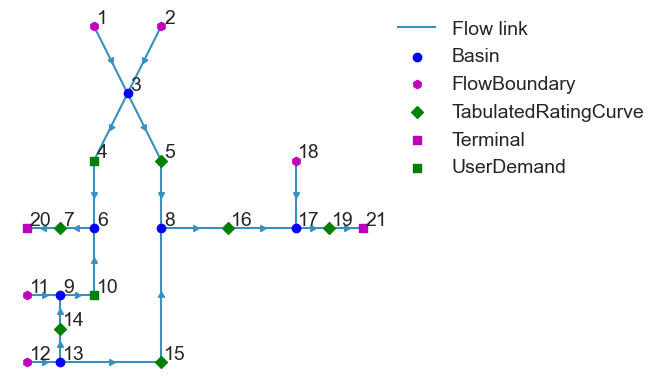

In [ ]:
project_dir = Path(".")
output_dir = project_dir / "output"
output_dir.mkdir(exist_ok=True)

starttime = "2018-10-01 00:00" 
# endtime = "2018-10-20 23:00"
endtime = "2018-10-31 00:00"

model = Model(
    starttime=starttime,
    endtime=endtime,
    crs="EPSG:25833",
)

inflow_Tuns = model.flow_boundary.add(
    Node(1, Point(-1,3), name="Tunsbergdalsvatn_inflow"),
    [
        flow_boundary.Time(
            time=tunsberg["time"],
            flow_rate=tunsberg["flow"],
        )
    ],
)

inflow_Fonn = model.flow_boundary.add(
    Node(2, Point(0,3), name="Fonndola_stream_intake"),
    [
        flow_boundary.Time(
            time=fonndola["time"],
            flow_rate=fonndola["flow"],
        )
    ],
)

reservoir_Tuns = model.basin.add(
    Node(3, Point(-0.5,2), name="Tunsbergdalsvatn"),
    [
        basin.Profile(
            level=[465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 478.2, 478.4, 478.6, 478.8, 479],
            area=[6435000, 6583000, 6717000, 6837999.99999999, 6968033.33333334,
                   7108699.25093638, 7269467.41573043, 7413949.99999996,
                   7522849.99999989, 7579000.00000001, 7618190.47619056, 7644809.52380944,
                   7665133.33333333, 7760015.38, 7768249.97, 7776045.08, 7783650.84, 7791032.56, 7798512.84
                    ], #
        ),
        basin.State(
            level = [477.381] # initial water level on Oct 1st 2018
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)

turbine_Leir = model.user_demand.add(
    Node(4, Point(-1, 1), name="Leirdola_turbine"),
    [
        user_demand.Time(
            demand=leirdola_turbine["discharge"].values,  
            time=leirdola_turbine["time"],
            return_factor=0.0,  
            min_level=440,  
            demand_priority=1,
        )
    ],
)

h = np.linspace(478.001, 479.0, 20)
Q = 200*(h-478)**(1.5)

spillway = model.tabulated_rating_curve.add(
    Node(5, Point(0,1), name = "Tunsbergdalsvatn_spillway"),
    [
        tabulated_rating_curve.Static(
            level=[478] + h.tolist(),
            flow_rate=[0.0] + Q.tolist(),
        )
    ],
)


confluence_1 = model.basin.add(
    Node(6, Point(-1, 0), name="confluence_1"),
    [
        basin.Profile(
            level=[0, 3],         
            area=[10, 20],     
        ),
        basin.State(
            level=[1],              
        ),           
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)

weir_1 = model.tabulated_rating_curve.add(
    Node(7, Point(-1.5, 0), name="weir_1"),
    [
        tabulated_rating_curve.Static(
            level=[0, 1, 2],
            flow_rate=[0, 100, 200]    
        )
    ]
)

confluence_2 = model.basin.add(
    Node(8, Point(0, 0), name="confluence_2"),
    [
        basin.Profile(
            level=[200, 203],         
            area=[1.0, 1.0],     
        ),
        basin.State(
            level=[201],             
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)


reservoir_Stygg = model.basin.add(
    Node(9, Point(-1.5,-1), name="Styggevatn"),
    [
        basin.Profile(
            level = [1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197,
                     1198, 1199, 1200, 1200.2, 1200.4, 1200.6, 1200.8, 1201.0],
        area = [7660374.07, 7699680.28, 7738986.49, 7778292.71, 7817598.92, 7856905.13, 
                7896211.35, 7935517.56, 7974823.77, 8014130.00, 8686463.02, 8704365.24, 8718274.17, 8732738.37, 
                8746881.55, 8760806.32
                    ], # area below HRWL is interpolated between 766034.07 and 8014130. No plausible stage-area 
                    # relationship found, see reservoir_volume.ipynb notebook.
        ),
        basin.State(
            level = [1193.660] # observed water level on Oct 1st 2018
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)

turbine_Jost = model.user_demand.add(
    Node(10, Point(-1, -1), name="Jostedal_turbine"),
    [
        user_demand.Time(
            demand=jostedal_turbine["discharge"].values,  
            time=jostedal_turbine["time"],
            return_factor=0.0,  
            min_level=1120,  
            demand_priority=1,
        )
    ],
)


inflow_Stygg = model.flow_boundary.add(
    Node(11, Point(-2,-1), name="Styggevatn_inflow"),
    [
        flow_boundary.Time(
            time=styggevatn["time"],
            flow_rate=styggevatn["flow"],
        )
    ],
)

inflow_streams = model.flow_boundary.add(
    Node(12, Point(-2,-2), name="inflow_streams"),
    [
        flow_boundary.Time(
            time=stream_intake["time"],
            flow_rate=stream_intake["flow"],
        )
    ],
)


stream_intakes = model.basin.add(
    Node(13, Point(-1.5, -2), name="stream_intakes"),
    [
        basin.Profile(
            level=[1202, 1203, 1204],
            area=[2, 4, 6],
        ),
        basin.State(
            level=[1203],              
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)

weir_2 = model.tabulated_rating_curve.add(
    Node(14, Point(-1.5, -1.5), name="weir_2"),
    [
        tabulated_rating_curve.Static(
            level=[1202, 1203, 1204],
            flow_rate=[0, 30, 63] 
        )
    ]
)

stream_intakes_spill = model.tabulated_rating_curve.add(
    Node(15, Point(0, -2), name="stream_intakes_spill"),
    [
        tabulated_rating_curve.Static(
            level=[1202, 1203, 1204],
            flow_rate=[0, 0, 200]   
        )
    ]
)

weir_3 = model.tabulated_rating_curve.add(
    Node(16, Point(1, 0), name="weir_3"),
    [
        tabulated_rating_curve.Static(
            level=[200, 201, 202],
            flow_rate=[0, 1e5, 2e5]   
        )
    ]
)


confluence_3 = model.basin.add(
    Node(17, Point(2, 0), name="confluence_3"),
    [
        basin.Profile(
            level=[150, 151, 152],         
            area=[1.0, 1.0, 1.0],     
        ),
        basin.State(
            level=[151],             
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)


Gaupne_res = model.flow_boundary.add(
    Node(18, Point(2,1), name="Gaupne_res"),
    [
        flow_boundary.Time(
            time=gaupne["time"],
            flow_rate=gaupne["flow"],
        )
    ],
)


weir_4 = model.tabulated_rating_curve.add(
    Node(19, Point(2.5, 0), name="weir_4"),
    [
        tabulated_rating_curve.Static(
            level=[150, 151, 152],
            flow_rate=[0, 1e5, 2e5]  
        )
    ]
)

sea1 = model.terminal.add(Node(20, Point(-2, 0), name="sea1"))
sea2 = model.terminal.add(Node(21, Point(3, 0), name="sea2"))

model.link.add(inflow_Tuns, reservoir_Tuns, name="inflow_Tuns")
model.link.add(inflow_Fonn, reservoir_Tuns, name="inflow_Fonndola") 
model.link.add(reservoir_Tuns, spillway, name="Tuns_spill")
model.link.add(spillway, confluence_2)
model.link.add(reservoir_Tuns, turbine_Leir, name="turbine Leirdøla")
model.link.add(turbine_Leir, confluence_1)
model.link.add(confluence_1, weir_1)
model.link.add(weir_1, sea1)
model.link.add(inflow_Stygg, reservoir_Stygg, name="inflow_Stygg")
model.link.add(inflow_streams, stream_intakes)
model.link.add(stream_intakes, weir_2, name="stream_intake_Jostedal")
model.link.add(weir_2, reservoir_Stygg)
model.link.add(reservoir_Stygg, turbine_Jost, name="turbine Jostedal")
model.link.add(turbine_Jost, confluence_1)
model.link.add(stream_intakes, stream_intakes_spill, name="Jostedal_stream_spill")
model.link.add(stream_intakes_spill, confluence_2)
model.link.add(confluence_2, weir_3)
model.link.add(weir_3, confluence_3)
model.link.add(Gaupne_res, confluence_3, name= "Gaupne residual")
model.link.add(confluence_3, weir_4, name="Flom Gaupne")
model.link.add(weir_4, sea2)
model.plot()


In [ ]:

# plt.plot(tunsberg["time"], tunsberg["flow"], label="Inflow Tuns")
# plt.plot(fonndola["time"], fonndola["flow"], label="Inflow Fonndola")
# plt.plot(stream_intake["time"], stream_intake["flow"], label="Inflow streams")
# plt.plot(styggevatn["time"], styggevatn["flow"], label="Inflow styggevatn")
# plt.plot(leirdola_turbine["time"], leirdola_turbine["discharge"], label="Turbine demand Leir")
# plt.plot(jostedal_turbine["time"], jostedal_turbine["discharge"], label="Turbine demand")
# plt.legend()

NameError: name 'stream_intake' is not defined

In [ ]:
toml_path = "Jost_Gaupne/ribasim.toml"
# model.write(toml_path) # remember to update the [solver] in the toml file, saveat = 3600
cli_path = "ribasim.exe"
run_ribasim(toml_path, cli_path=cli_path, threads=1)

┌ Info: Starting a Ribasim simulation.
│   toml_path = "Jost_Gaupne\\ribasim.toml"
│   cli.ribasim_version = "2025.6.0"
│   starttime = 2018-10-01T00:00:00
│   endtime = 2018-10-31T00:00:00
└   threads = 1


[ Info: Computation time: 2 seconds, 448 milliseconds
[ Info: The model finished successfully.


In [ ]:
# result_file = "results_20_9th" # 20% increased precip, full turbine from 9th Oct
# result_file = "results_20_8th" # 20% increased precip, full turbine from 8th Oct
# result_file = "results_20_7th" # 20% increased precip, full turbine from 7th Oct
# result_file = "results_20_6th" # 20% increased precip, full turbine from 6th Oct
result_file = "results_ex0" # Observed turbine discharge, default
# result_file = "results_ex1" # observed inflow forcing + observed turbine until 6th October, then max production
# result_file = "results_ex2" # Observed inflow forcing, turbine discharge following the EC DOD strategy
# result_file = "results_ex3_7th" # Observed inflow forcing + observed turbine until 7th October, then max production
# result_file = "results_ex3_8th" # Observed inflow forcing + observed turbine until 8th October, then max production
# result_file = "results_ex3_9th" # Observed inflow forcing + observed turbine until 9th October, then max production
# result_file = "results_no" # Closed power station, no turbine discharge. Observed inflow forcing. 
df_reservoir = pd.read_feather(f"Jost_Gaupne/{result_file}/basin.arrow")

df_flow = pd.read_feather(f"Jost_Gaupne/{result_file}/flow.arrow")

df_allocation_flow = pd.read_feather(f"Jost_Gaupne/{result_file}/allocation_flow.arrow")

# print(df_flow.head(40))
# print(df_allocation_flow.head(40))

# print(df_flow["link_id"].unique())
# print(model.link.df.index)

# print(df_reservoir.head())
df_node9 = df_reservoir[df_reservoir["node_id"] == 9]
print(df_node9.head())

                  time  node_id        level       storage  inflow_rate  \
3  2018-10-01 00:00:00        9  1193.660000  2.830023e+07     9.602491   
9  2018-10-01 01:00:00        9  1193.664429  2.833480e+07     9.491514   
15 2018-10-01 02:00:00        9  1193.668808  2.836897e+07     9.384514   
21 2018-10-01 03:00:00        9  1193.673136  2.840276e+07     9.280417   
27 2018-10-01 04:00:00        9  1193.677417  2.843617e+07     9.178510   

    outflow_rate  storage_rate  precipitation  surface_runoff  evaporation  \
3            0.0      9.602491            0.0             0.0          0.0   
9            0.0      9.491514            0.0             0.0          0.0   
15           0.0      9.384514            0.0             0.0          0.0   
21           0.0      9.280417            0.0             0.0          0.0   
27           0.0      9.178510            0.0             0.0          0.0   

    drainage  infiltration  balance_error  relative_error  convergence  
3      

### Plotting Styggevatn water levels (node id 9)

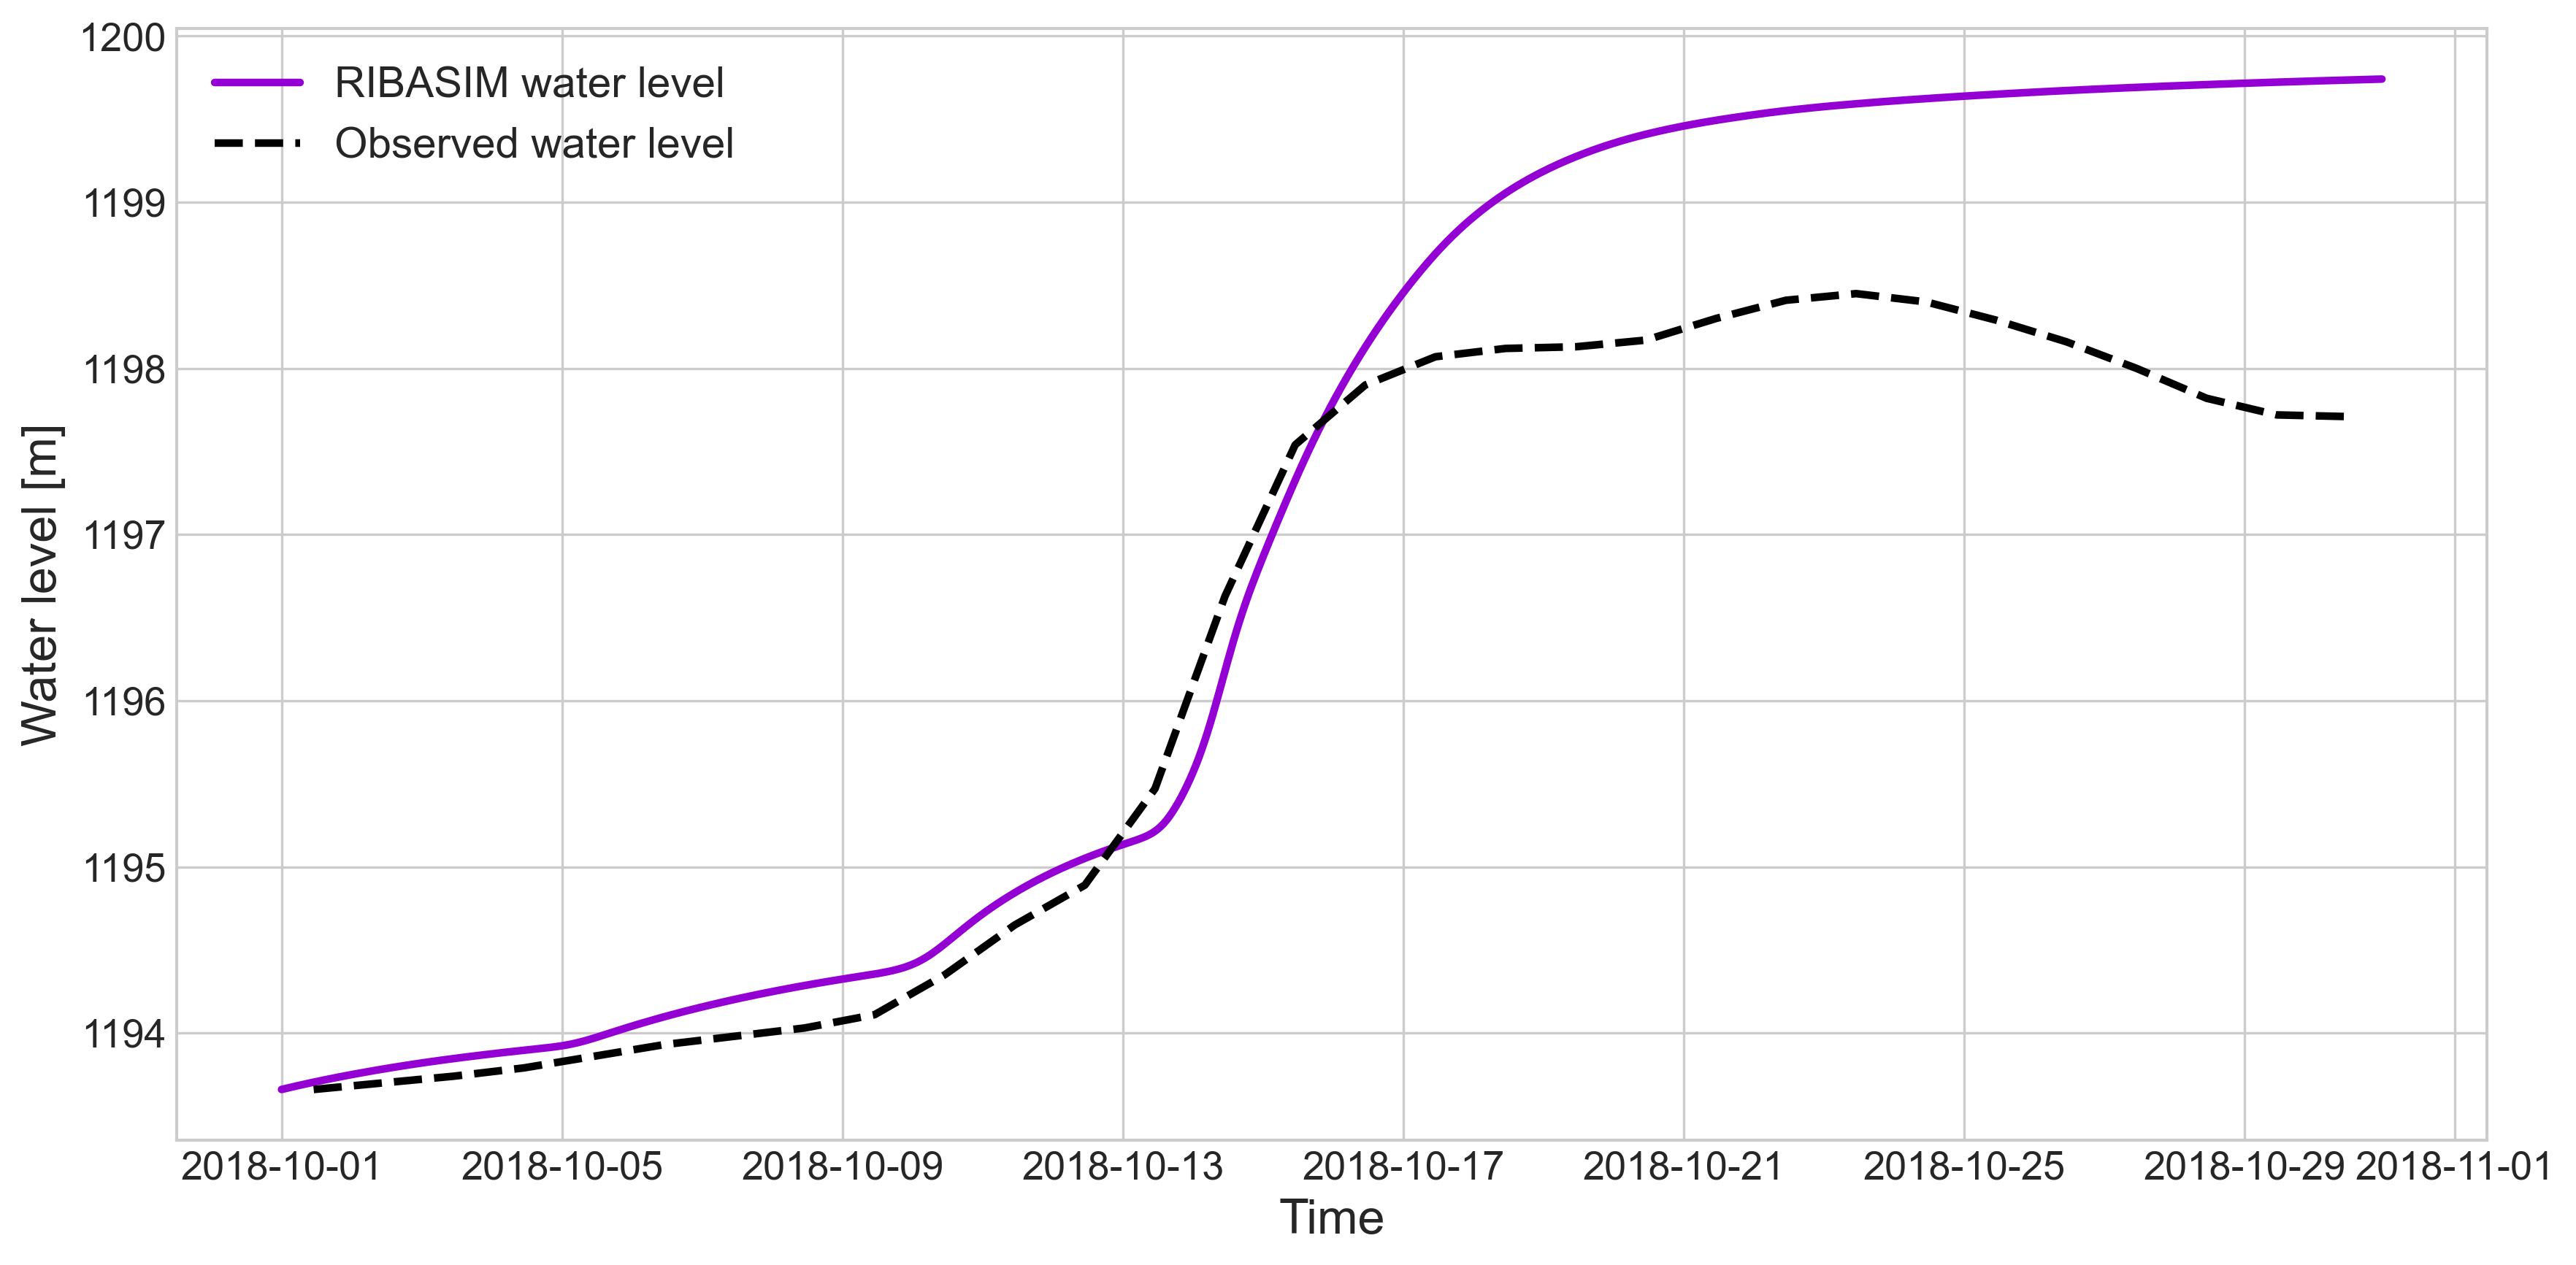

1198.45
1199.7411926888458


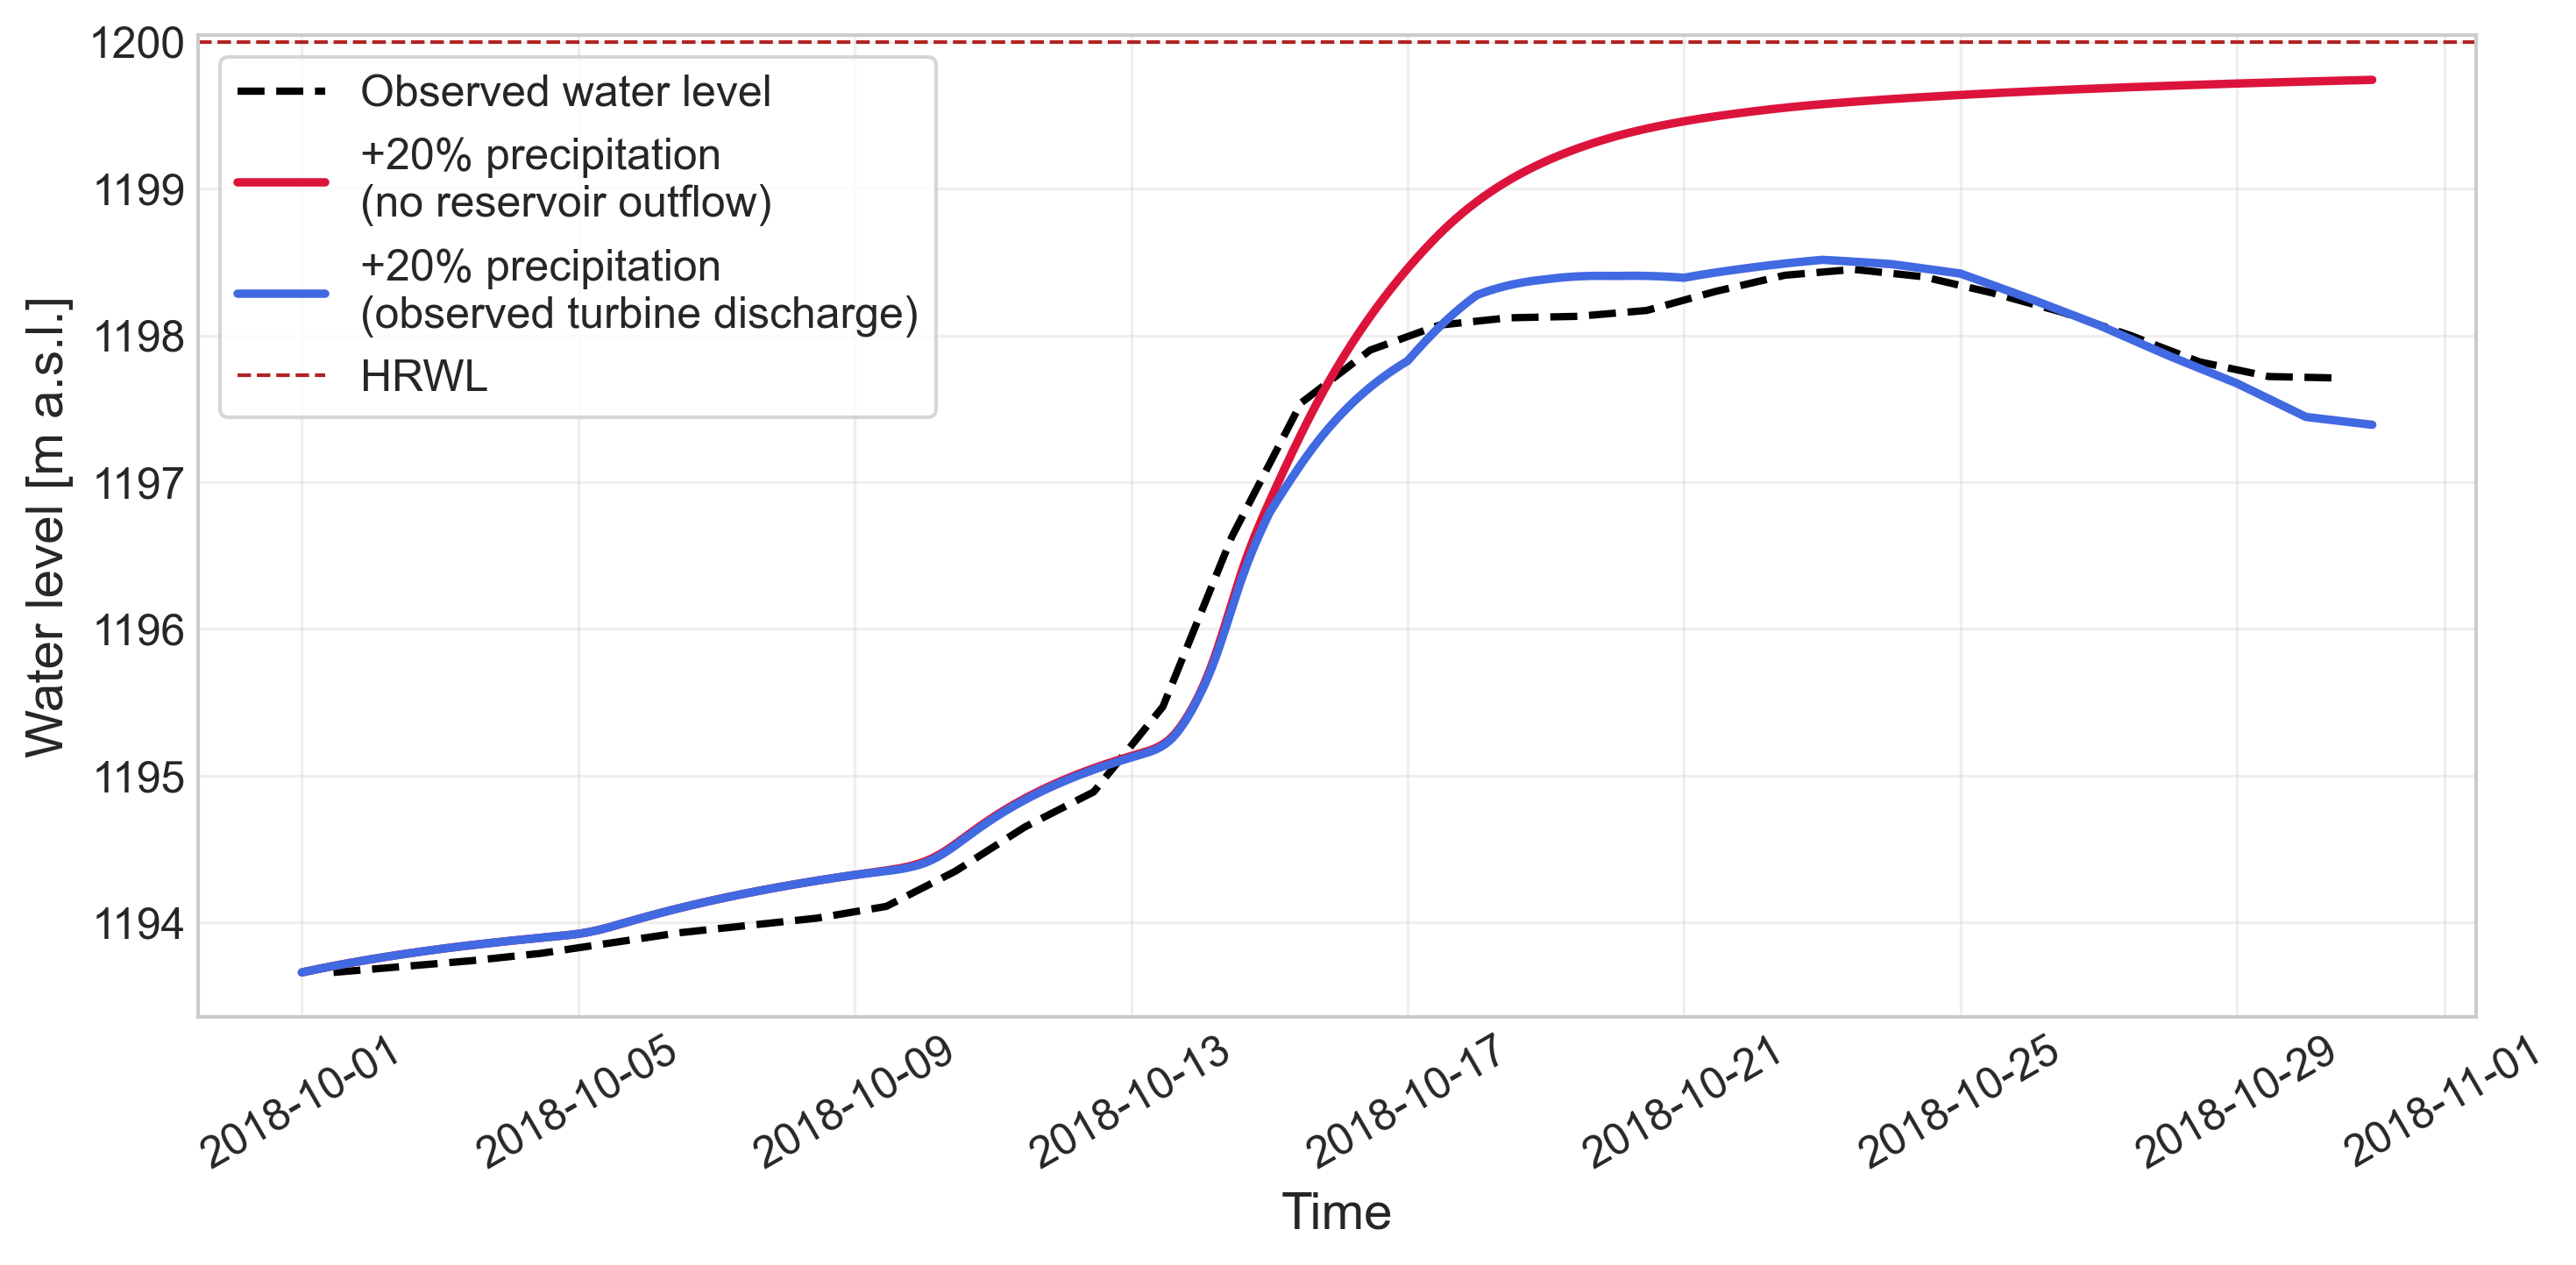

Observed water level peak:
1198.45 m

+20% precipitation (observed operation):
1198.51 m

+20% precipitation (no outflow):
1199.74 m


In [ ]:
result_file = "results_20_no_2nd"
df_reservoir = pd.read_feather(f"Jost_Gaupne/{result_file}/basin.arrow")

df_node9 = df_reservoir[df_reservoir["node_id"] == 9]

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

obs_wl = pd.read_csv(
    "../stygg_vannstand.csv",
    sep=";",
    skiprows=2,
    decimal=","
)

obs_wl.columns = ["time", "water_level", "corrected", "controlled"]

obs_wl["time"] = pd.to_datetime(obs_wl["time"])
mask = (
    (obs_wl["time"] >= "2018-10-01 00:00:00") &
    (obs_wl["time"] <= "2018-10-31 00:00:00")
)

oct_data = obs_wl.loc[mask]
oct_levels = oct_data["water_level"]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_node9["time"],
    df_node9["level"],
    linewidth=2.5,
    label="RIBASIM water level",
    c="darkviolet",
)

ax.plot(
    oct_data["time"],
    oct_levels,
    c = "black",
    linewidth=2.5,
    linestyle="--",
    label="Observed water level"
)

ax.set_xlabel("Time")
ax.set_ylabel("Water level [m]")

#ax.set_title("Styggevatn: observed water level development vs. RIBASIM water level", fontsize=18)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()
print(oct_levels.max())
print(df_node9["level"].max())


# +20% precipitation with observed operation
df_obs = pd.read_feather(
    "Jost_Gaupne/results_20_obs/basin.arrow"
)

# +20% precipitation with no turbine discharge
df_no = pd.read_feather(
    "Jost_Gaupne/results_20_no_2nd/basin.arrow"
)

for df in [df_obs, df_no]:
    df["time"] = pd.to_datetime(df["time"])


df_obs_9 = df_obs[df_obs["node_id"] == 9]
df_no_9  = df_no[df_no["node_id"] == 9]

obs_wl = pd.read_csv(
    "../stygg_vannstand.csv",
    sep=";",
    skiprows=2,
    decimal=","
)

obs_wl.columns = [
    "time",
    "water_level",
    "corrected",
    "controlled"
]

obs_wl["time"] = pd.to_datetime(obs_wl["time"])

mask = (
    (obs_wl["time"] >= "2018-10-01") &
    (obs_wl["time"] <= "2018-10-31")
)

oct_data = obs_wl.loc[mask]

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    oct_data["time"],
    oct_data["water_level"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="Observed water level"
)

ax.plot(
    df_no_9["time"],
    df_no_9["level"],
    color="crimson",
    linewidth=2.3,
    label="+20% precipitation\n(no reservoir outflow)"
)

ax.plot(
    df_obs_9["time"],
    df_obs_9["level"],
    color="royalblue",
    linewidth=2.3,
    label="+20% precipitation\n(observed turbine discharge)"
)


# HRWL
ax.axhline(
    y=1200,
    color="firebrick",
    linestyle="--",
    linewidth=1,
    label="HRWL"
)

ax.set_xlabel("Time")
ax.set_ylabel("Water level [m a.s.l.]")


ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="0.8"
)

ax.grid(alpha=0.3)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

print("Observed water level peak:")
print(round(oct_data["water_level"].max(), 2), "m")

print("\n+20% precipitation (observed operation):")
print(round(df_obs_9["level"].max(), 2), "m")

print("\n+20% precipitation (no outflow):")
print(round(df_no_9["level"].max(), 2), "m")



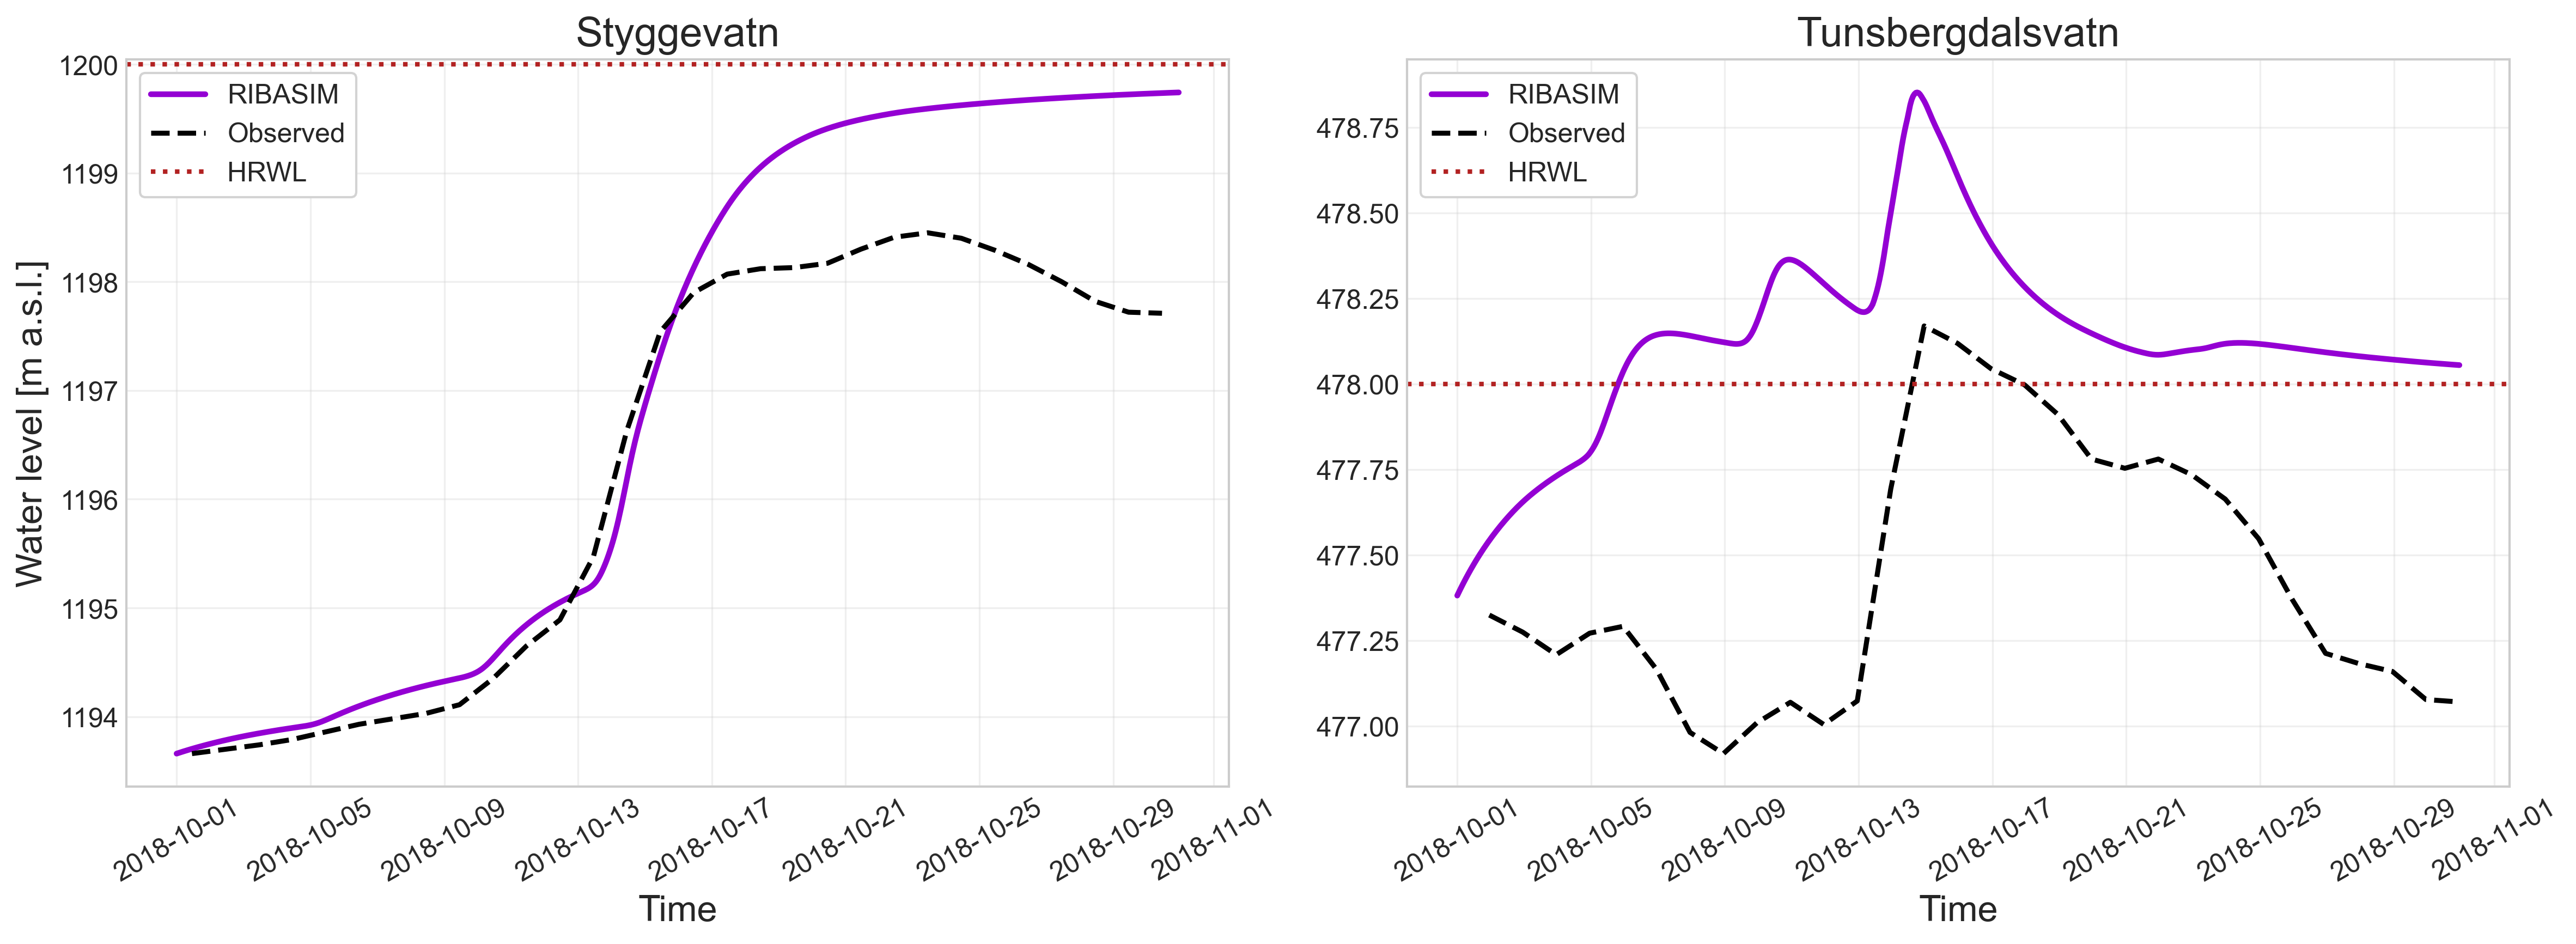

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

def load_observed(filepath):

    obs = pd.read_csv(
        filepath,
        sep=";",
        skiprows=2,
        decimal=","
    )

    obs.columns = ["time", "water_level", "corrected", "controlled"]

    obs["time"] = pd.to_datetime(obs["time"])

    mask = (
        (obs["time"] >= "2018-10-01 00:00:00") &
        (obs["time"] <= "2018-10-31 00:00:00")
    )

    return obs.loc[mask].copy()

obs_stygge = load_observed("../stygg_vannstand.csv")
obs_tuns = load_observed("../tuns_vannstand.csv")

ribasim_stygge = df_reservoir[df_reservoir["node_id"] == 9].copy()
ribasim_tuns = df_reservoir[df_reservoir["node_id"] == 3].copy()

obs_stygge["time"] = (
    pd.to_datetime(obs_stygge["time"], utc=True)
    .dt.tz_localize(None)
)

obs_tuns["time"] = (
    pd.to_datetime(obs_tuns["time"], utc=True)
    .dt.tz_localize(None)
)

merged_stygge = pd.merge(
    ribasim_stygge[["time", "level"]],
    obs_stygge[["time", "water_level"]],
    on="time",
    how="inner"
)

rmse_stygge = np.sqrt(mean_squared_error(
    merged_stygge["water_level"],
    merged_stygge["level"]
))

bias_stygge = (
    merged_stygge["level"] -
    merged_stygge["water_level"]
).mean()

merged_tuns = pd.merge(
    ribasim_tuns[["time", "level"]],
    obs_tuns[["time", "water_level"]],
    on="time",
    how="inner"
)

rmse_tuns = np.sqrt(mean_squared_error(
    merged_tuns["water_level"],
    merged_tuns["level"]
))

bias_tuns = (
    merged_tuns["level"] -
    merged_tuns["water_level"]
).mean()

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharex=True
)

ax = axes[0]

ax.plot(
    ribasim_stygge["time"],
    ribasim_stygge["level"],
    linewidth=2.5,
    color="darkviolet",
    label="RIBASIM"
)

ax.plot(
    obs_stygge["time"],
    obs_stygge["water_level"],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Observed"
)

# HRWL
ax.axhline(
    y=1200,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Styggevatn")
ax.set_ylabel("Water level [m a.s.l.]")

# Statistics text box
# ax.text(
#     0.02,
#     0.02,
#     (
#         f"RMSE = {rmse_stygge:.2f} m\n"
#         f"Bias = {bias_stygge:.2f} m"
#     ),
#     transform=ax.transAxes,
#     fontsize=11,
#     verticalalignment="bottom",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="grey",
#         alpha=0.9
#     )
# )

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="lightgrey"
)

ax = axes[1]

ax.plot(
    ribasim_tuns["time"],
    ribasim_tuns["level"],
    linewidth=2.5,
    color="darkviolet",
    label="RIBASIM"
)

ax.plot(
    obs_tuns["time"],
    obs_tuns["water_level"],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Observed"
)

# HRWL
ax.axhline(
    y=478,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Tunsbergdalsvatn")

# Statistics text box
# ax.text(
#     0.02,
#     0.02,
#     (
#         f"RMSE = {rmse_tuns:.2f} m\n"
#         f"Bias = {bias_tuns:.2f} m"
#     ),
#     transform=ax.transAxes,
#     fontsize=11,
#     verticalalignment="bottom",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="grey",
#         alpha=0.9
#     )
# )

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="lightgrey"
)

for ax in axes:
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()

Styggevatn - Baseline max level: 1198.188116614719
Styggevatn - No turbine discharge max level: 1199.4442395058554
Tunsbergdalsvatn - Baseline max level: 478.43366078529334
Tunsbergdalsvatn - Pre-release 6 Oct max level: 478.2578753910568
Tunsbergdalsvatn - Pre-release 7 Oct max level: 478.34025638168833
Tunsbergdalsvatn - Pre-release 8 Oct max level: 478.37008805099185


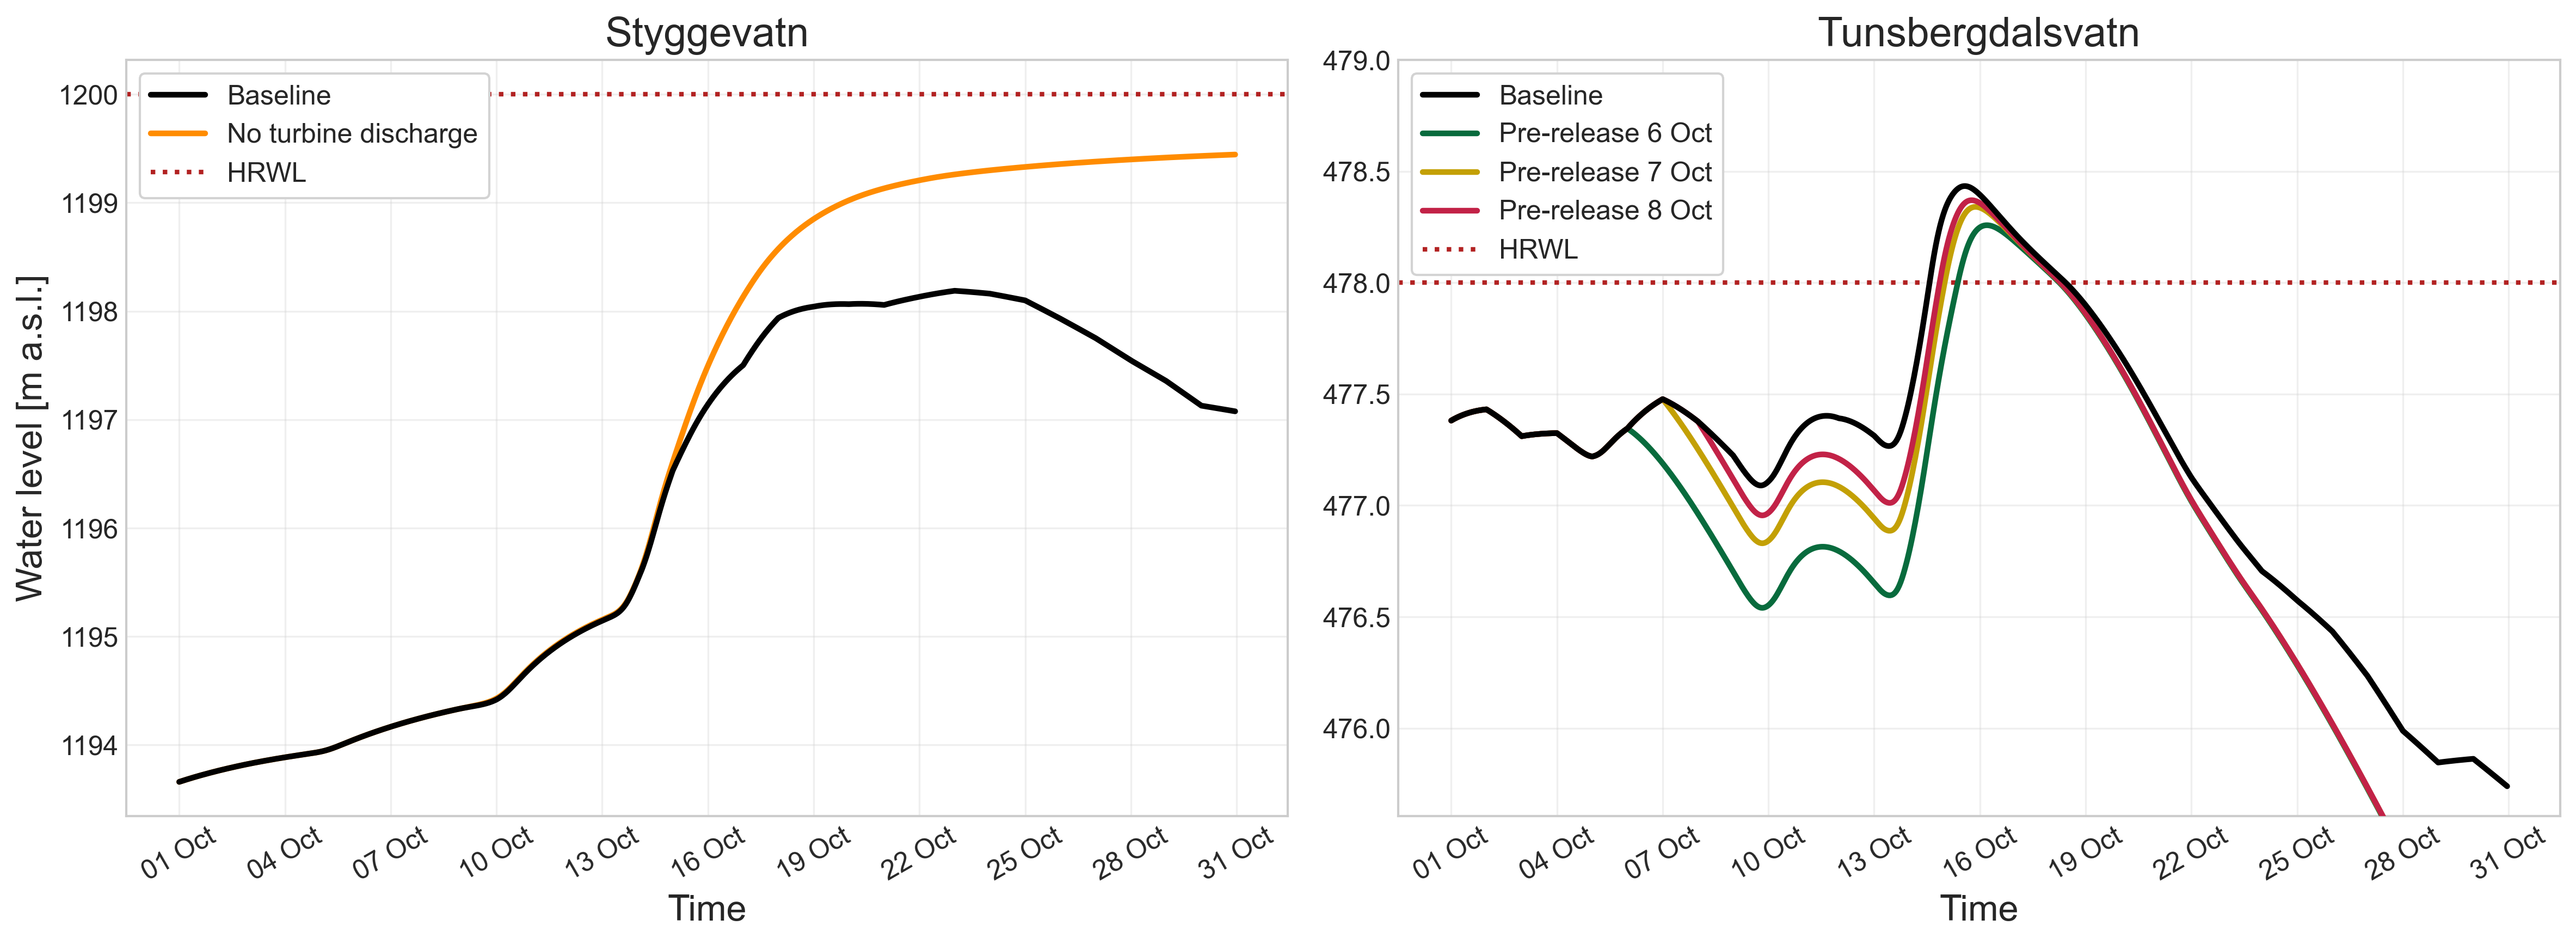

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

scenarios_stygge = {
    "Baseline": "results_ex0",
    "No turbine discharge": "results_no",
}

scenarios_tuns = {
    "Baseline": "results_ex0",
    "Pre-release 6 Oct": "results_ex1",
    "Pre-release 7 Oct": "results_ex3_7th",
    "Pre-release 8 Oct": "results_ex3_8th",
}

colors = {
    "Baseline": "black",
    "No turbine discharge": "darkorange",

    "Pre-release 6 Oct": "#086b3d",
    "Pre-release 7 Oct": "#C3A005",
    "Pre-release 8 Oct": "#c22247",
}

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharex=True
)

ax = axes[0]

for label, result_file in scenarios_stygge.items():

    df_reservoir = pd.read_feather(
        f"Jost_Gaupne/{result_file}/basin.arrow"
    )

    df_node = df_reservoir[df_reservoir["node_id"] == 9]

    ax.plot(
        df_node["time"],
        df_node["level"],
        linewidth=2.5,
        label=label,
        color=colors[label],
        zorder=10 if label == "Baseline" else 3
    )

    print(
        f"Styggevatn - {label} max level:",
        df_node["level"].max()
    )

# HRWL
ax.axhline(
    y=1200,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Styggevatn")
ax.set_ylabel("Water level [m a.s.l.]")

legend = ax.legend(
    loc="upper left",
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgrey")
legend.get_frame().set_alpha(1)

ax = axes[1]

for label, result_file in scenarios_tuns.items():

    df_reservoir = pd.read_feather(
        f"Jost_Gaupne/{result_file}/basin.arrow"
    )

    df_node = df_reservoir[df_reservoir["node_id"] == 3]

    ax.plot(
        df_node["time"],
        df_node["level"],
        linewidth=2.5,
        label=label,
        color=colors[label],
        zorder=10 if label == "Baseline" else 3
    )
    ax.set_ylim(top=479)

    print(
        f"Tunsbergdalsvatn - {label} max level:",
        df_node["level"].max()
    )

# HRWL
ax.axhline(
    y=478,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Tunsbergdalsvatn")

legend = ax.legend(
    loc="upper left",
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("lightgrey")
legend.get_frame().set_alpha(1)

for ax in axes:

    ax.set_xlabel("Time")

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b')
    )

    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=3)
    )

    ax.tick_params(
        axis='x',
        rotation=30
    )

    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

No turbine discharge max level: 1199.4442395058554
Baseline (observed forcing and turbine discharge) max level: 1198.188116614719
Maximum turbine discharge from 6 Oct max level: 1194.7836951464865


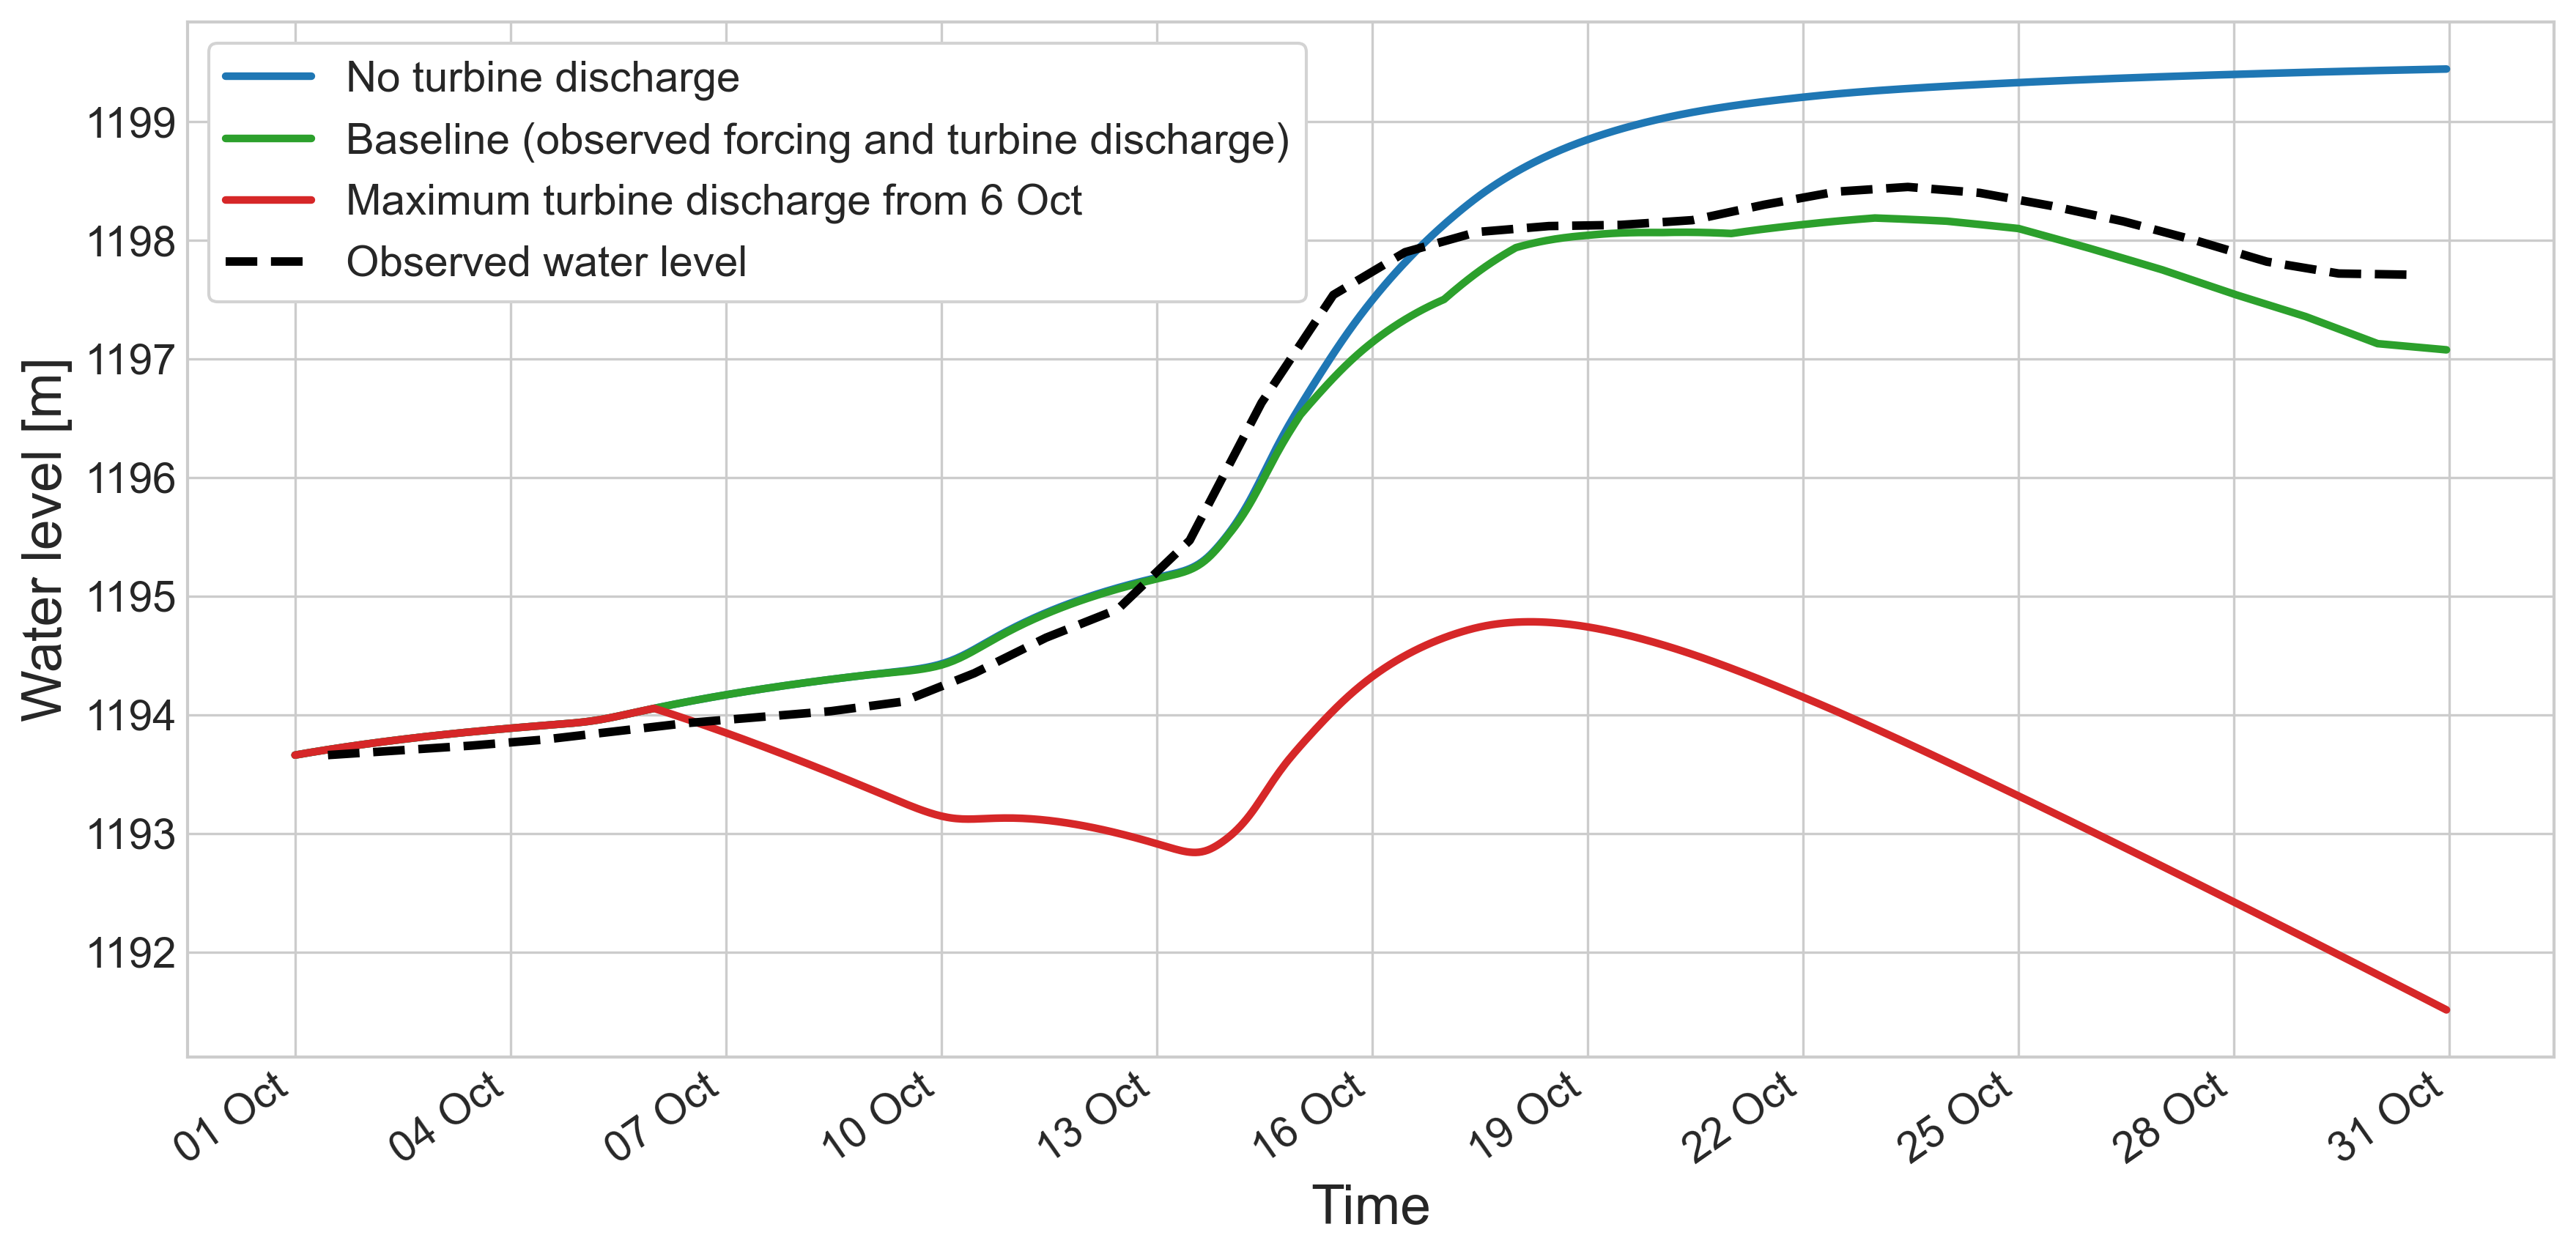

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# =========================
# scenario files:
# =========================
# result_file = "results_ex0" # Observed everything, default
# result_file = "results_ex1" # observed inflow + observed turbine until 6th October, then max production
# result_file = "results_ex2" # Observed inflow, turbine discharge following the EC DOD strategy
# result_file = "results_ex3_7th" # Pre-release 7 October
# result_file = "results_ex3_8th" # Pre-release 8 October
# result_file = "results_ex3_9th" # Pre-release 9 October
# result_file = "results_no" # Closed power station, no turbine discharge. Observed everything. 
scenarios = {
    "No turbine discharge": "results_no",
    "Baseline (observed forcing and turbine discharge)": "results_ex0",
    "Maximum turbine discharge 6 Oct": "results_ex1",
}

colors = {
    "No turbine discharge": "#1f77b4",   
    "Baseline (observed forcing and turbine discharge)": "#2ca02c",
    "Maximum turbine discharge from 6 Oct": "#d62728",  
}

obs_wl = pd.read_csv(
    "../stygg_vannstand.csv",
    sep=";",
    skiprows=2,
    decimal=","
)

obs_wl.columns = ["time", "water_level", "corrected", "controlled"]
obs_wl["time"] = pd.to_datetime(obs_wl["time"])

mask = (
    (obs_wl["time"] >= "2018-10-01") &
    (obs_wl["time"] <= "2018-10-31")
)

oct_data = obs_wl.loc[mask]

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, ax = plt.subplots(figsize=(12, 6))

for label, result_file in scenarios.items():

    df_reservoir = pd.read_feather(f"Jost_Gaupne/{result_file}/basin.arrow")
    df_node9 = df_reservoir[df_reservoir["node_id"] == 9]

    ax.plot(
        df_node9["time"],
        df_node9["level"],
        linewidth=2.5,
        label=label,
        color=colors.get(label, None)  
    )

    print(f"{label} max level:", df_node9["level"].max())

ax.plot(
    oct_data["time"],
    oct_data["water_level"],
    color="black",
    linewidth=2.8,
    linestyle="--",
    label="Observed water level"
)

ax.set_xlabel("Time")
ax.set_ylabel("Water level [m]")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

plt.xticks(rotation=35, ha="right")

legend = ax.legend(
    loc="upper left",
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()

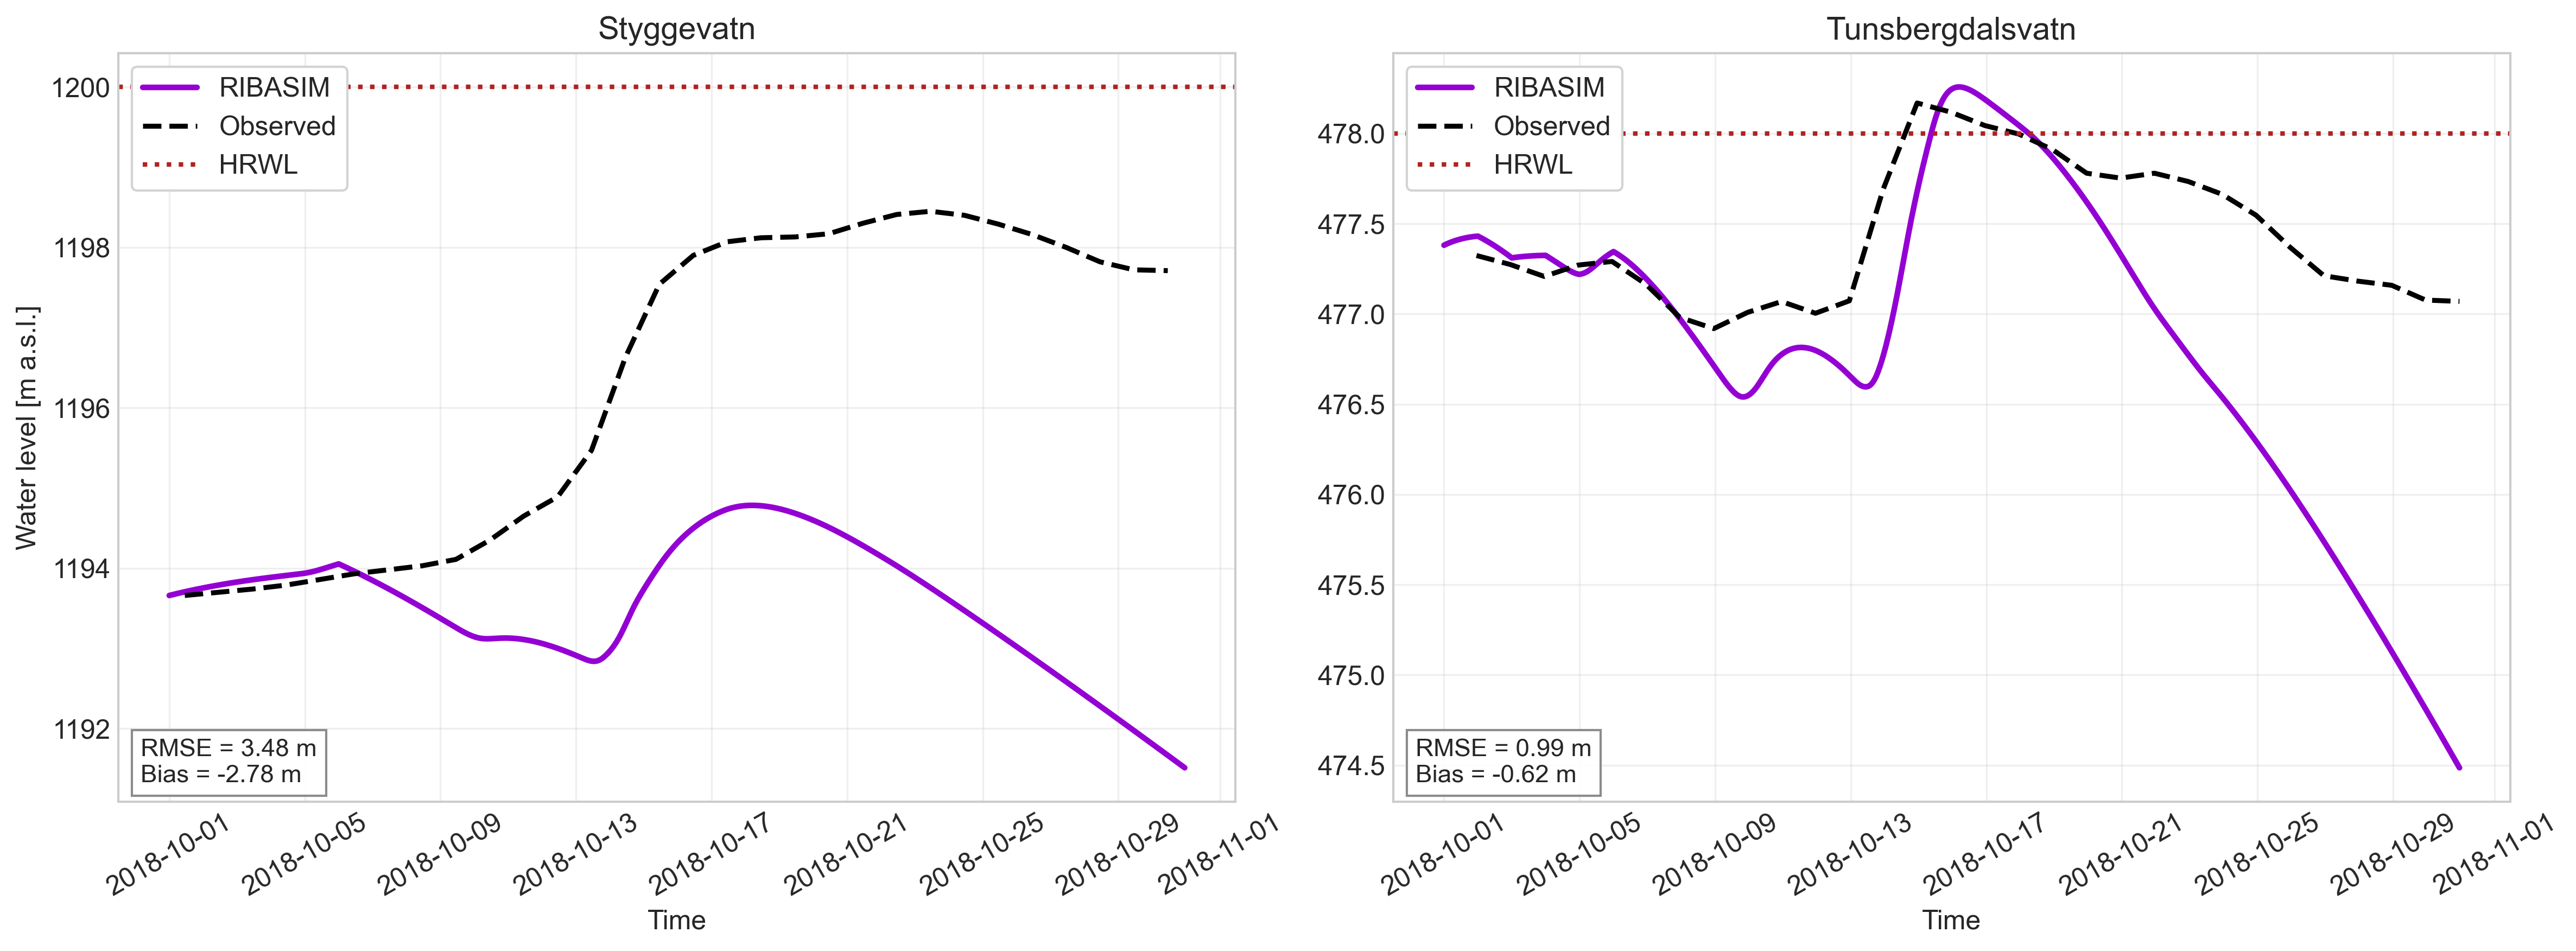

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300
})

def load_observed(filepath):

    obs = pd.read_csv(
        filepath,
        sep=";",
        skiprows=2,
        decimal=","
    )

    obs.columns = ["time", "water_level", "corrected", "controlled"]

    obs["time"] = pd.to_datetime(obs["time"])

    mask = (
        (obs["time"] >= "2018-10-01 00:00:00") &
        (obs["time"] <= "2018-10-31 00:00:00")
    )

    return obs.loc[mask].copy()

obs_stygge = load_observed("../stygg_vannstand.csv")
obs_tuns = load_observed("../tuns_vannstand.csv")


ribasim_stygge = df_reservoir[df_reservoir["node_id"] == 9].copy()
ribasim_tuns = df_reservoir[df_reservoir["node_id"] == 3].copy()

obs_stygge["time"] = (
    pd.to_datetime(obs_stygge["time"], utc=True)
    .dt.tz_localize(None)
)

obs_tuns["time"] = (
    pd.to_datetime(obs_tuns["time"], utc=True)
    .dt.tz_localize(None)
)

merged_stygge = pd.merge(
    ribasim_stygge[["time", "level"]],
    obs_stygge[["time", "water_level"]],
    on="time",
    how="inner"
)

rmse_stygge = np.sqrt(mean_squared_error(
    merged_stygge["water_level"],
    merged_stygge["level"]
))

bias_stygge = (
    merged_stygge["level"] -
    merged_stygge["water_level"]
).mean()

merged_tuns = pd.merge(
    ribasim_tuns[["time", "level"]],
    obs_tuns[["time", "water_level"]],
    on="time",
    how="inner"
)

rmse_tuns = np.sqrt(mean_squared_error(
    merged_tuns["water_level"],
    merged_tuns["level"]
))

bias_tuns = (
    merged_tuns["level"] -
    merged_tuns["water_level"]
).mean()

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharex=True
)

ax = axes[0]

ax.plot(
    ribasim_stygge["time"],
    ribasim_stygge["level"],
    linewidth=2.5,
    color="darkviolet",
    label="RIBASIM"
)

ax.plot(
    obs_stygge["time"],
    obs_stygge["water_level"],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Observed"
)

# HRWL
ax.axhline(
    y=1200,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Styggevatn")
ax.set_ylabel("Water level [m a.s.l.]")

ax.text(
    0.02,
    0.02,
    (
        f"RMSE = {rmse_stygge:.2f} m\n"
        f"Bias = {bias_stygge:.2f} m"
    ),
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        alpha=0.9
    )
)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="lightgrey"
)

ax = axes[1]

ax.plot(
    ribasim_tuns["time"],
    ribasim_tuns["level"],
    linewidth=2.5,
    color="darkviolet",
    label="RIBASIM"
)

ax.plot(
    obs_tuns["time"],
    obs_tuns["water_level"],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="Observed"
)

# HRWL
ax.axhline(
    y=478,
    color="firebrick",
    linestyle=":",
    linewidth=2,
    label="HRWL"
)

ax.set_title("Tunsbergdalsvatn")

# Statistics text box
ax.text(
    0.02,
    0.02,
    (
        f"RMSE = {rmse_tuns:.2f} m\n"
        f"Bias = {bias_tuns:.2f} m"
    ),
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="grey",
        alpha=0.9
    )
)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="lightgrey"
)

for ax in axes:
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()

### Plot of Gaupne discharge with observed inflow forcing 

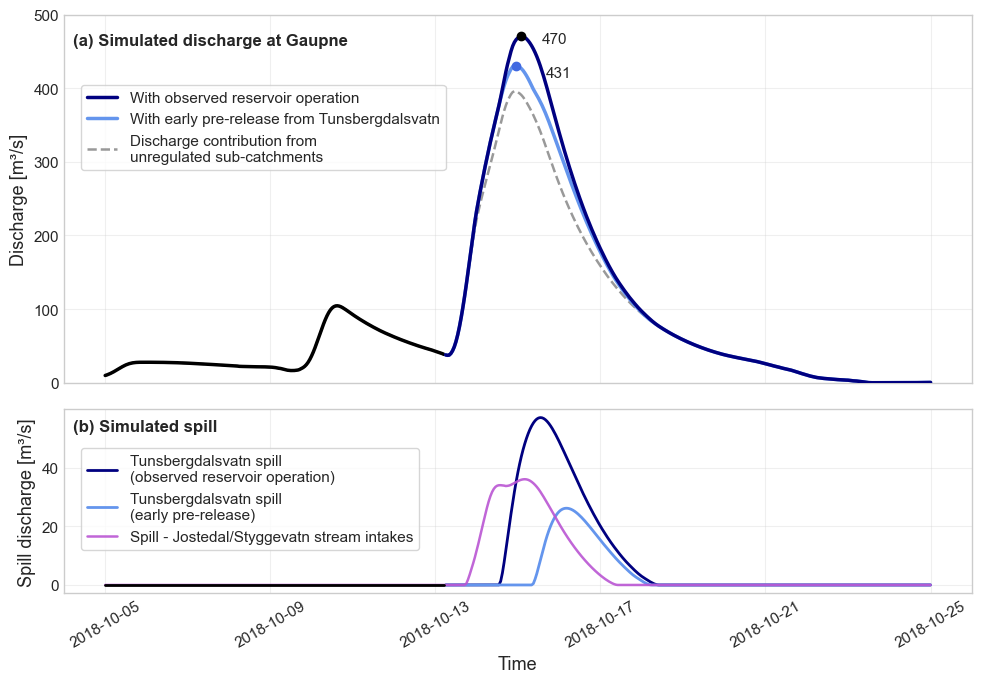

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df1 = pd.read_feather(
    "Jost_Gaupne/results_ex1/flow.arrow"
)  # early pre-release

df2 = pd.read_feather(
    "Jost_Gaupne/results_ex0/flow.arrow"
)  # observed pre-release

for df in [df1, df2]:
    df["time"] = pd.to_datetime(df["time"])

def extract(df, link_id):
    return df[df["link_id"] == link_id]

gau1 = extract(df1, 20)   # early pre-release
gau2 = extract(df2, 20)   # observed pre-release

gau_unreg = extract(df1, 19) # contribution from unregulated part of catchment

spill_tuns_1 = extract(df1, 3)
spill_tuns_2 = extract(df2, 3)

spill_stream_1 = extract(df1, 15)
spill_stream_2 = extract(df2, 15)

start = "2018-10-05"
end   = "2018-10-25"

def clip(df):
    return df[
        (df["time"] >= start) &
        (df["time"] <= end)
    ]

gau1 = clip(gau1)
gau2 = clip(gau2)

gau_unreg = clip(gau_unreg)

spill_tuns_1 = clip(spill_tuns_1)
spill_tuns_2 = clip(spill_tuns_2)

spill_stream_1 = clip(spill_stream_1)
spill_stream_2 = clip(spill_stream_2)

def get_peak(df):

    idx = df["flow_rate"].idxmax()

    return (
        df.loc[idx, "flow_rate"],
        df.loc[idx, "time"]
    )

peak1, time1 = get_peak(gau1)
peak2, time2 = get_peak(gau2)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

plt.style.use("seaborn-v0_8-whitegrid")

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

split_time = pd.Timestamp("2018-10-13 06:00")

gau_shared = gau2[gau2["time"] < split_time]

ax1.plot(
    gau_shared["time"],
    gau_shared["flow_rate"],
    color="black",
    linewidth=2.5
)

gau2_after = gau2[gau2["time"] >= split_time]

ax1.plot(
    gau2_after["time"],
    gau2_after["flow_rate"],
    color="navy",
    linewidth=2.5,
    zorder=3,
    label="With observed reservoir operation"
)

gau1_after = gau1[gau1["time"] >= split_time]

ax1.plot(
    gau1_after["time"],
    gau1_after["flow_rate"],
    color="cornflowerblue",
    linewidth=2.5,
    zorder=2,
    label="With early pre-release from Tunsbergdalsvatn"
)

ax1.plot(
    gau_unreg["time"],
    gau_unreg["flow_rate"],
    color="gray",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
    zorder=1,
    label="Discharge contribution from\nunregulated sub-catchments"
)

ax1.scatter(
    time2,
    peak2,
    color="black",
    zorder=5
)

ax1.scatter(
    time1,
    peak1,
    color="royalblue",
    zorder=5
)

ax1.annotate(
    f"{peak2:.0f}",
    (time2, peak2),
    xytext=(15, -5),
    textcoords="offset points",
    fontsize=11
)

ax1.annotate(
    f"{peak1:.0f}",
    (time1, peak1),
    xytext=(21, -8),
    textcoords="offset points",
    fontsize=11
)

ax1.text(
    0.01,
    0.95,
    "(a) Simulated discharge at Gaupne",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

ax1.set_ylabel("Discharge [m³/s]")

ax1.set_ylim(0, 500)

ax1.grid(alpha=0.3)

ax1.legend(
    loc="upper left",
    frameon= True,
    bbox_to_anchor=(0.01, 0.83),
    facecolor="white",
    edgecolor="0.8"
)

spill_shared = spill_tuns_2[spill_tuns_2["time"] < split_time]

ax2.plot(
    spill_shared["time"],
    spill_shared["flow_rate"],
    color="black",
    linewidth=2,
    zorder=5,
)

# Observed operation spill
spill_tuns_2_after = spill_tuns_2[
    spill_tuns_2["time"] >= split_time
]

ax2.plot(
    spill_tuns_2_after["time"],
    spill_tuns_2_after["flow_rate"],
    color="navy",
    linewidth=2,
    label="Tunsbergdalsvatn spill\n(observed reservoir operation)",
)

# Maximum turbine discharge spill
spill_tuns_1_after = spill_tuns_1[
    spill_tuns_1["time"] >= split_time
]

ax2.plot(
    spill_tuns_1_after["time"],
    spill_tuns_1_after["flow_rate"],
    color="cornflowerblue",
    linewidth=2,
    label="Tunsbergdalsvatn spill\n(early pre-release)",
)

# Spill from stream intakes
ax2.plot(
    spill_stream_1["time"],
    spill_stream_1["flow_rate"],
    color="mediumorchid",
    linewidth=1.8,
    alpha=0.9,
    label="Spill - Jostedal/Styggevatn stream intakes"
)

ax2.text(
    0.01,
    0.95,
    "(b) Simulated spill",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

ax2.set_ylabel("Spill discharge [m³/s]")

ax2.set_xlabel("Time")

ax2.grid(alpha=0.3)

ax2.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.83),
    frameon=True,
    facecolor="white",
    edgecolor="0.8"
)

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### Plot of Gaupne discharge with 20% increased precipitation forcing

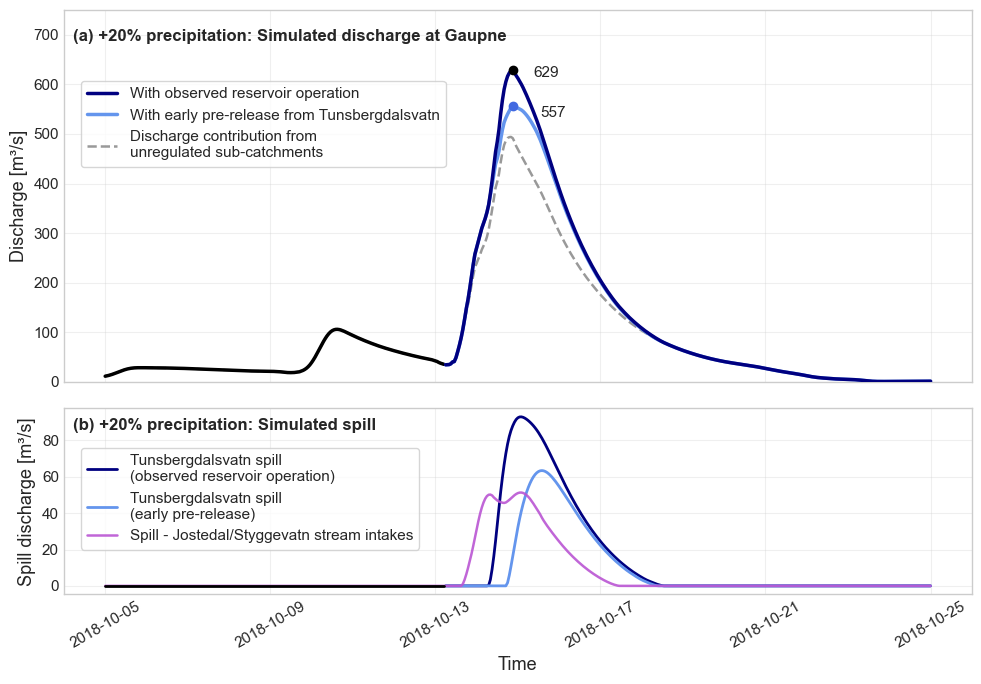

In [ ]:

df2 = pd.read_feather(
    "Jost_Gaupne/results_20_obs/flow.arrow"
)  # early pre-release

df1 = pd.read_feather(
    "Jost_Gaupne/results_20_6th/flow.arrow"
)  # observed pre-release

for df in [df1, df2]:
    df["time"] = pd.to_datetime(df["time"])

def extract(df, link_id):
    return df[df["link_id"] == link_id]

gau1 = extract(df1, 20)   # early pre-release
gau2 = extract(df2, 20)   # observed pre-release

gau_unreg = extract(df1, 19) # contribution from unregulated part of catchment

spill_tuns_1 = extract(df1, 3)
spill_tuns_2 = extract(df2, 3)

spill_stream_1 = extract(df1, 15)
spill_stream_2 = extract(df2, 15)

start = "2018-10-05"
end   = "2018-10-25"

def clip(df):
    return df[
        (df["time"] >= start) &
        (df["time"] <= end)
    ]

gau1 = clip(gau1)
gau2 = clip(gau2)

gau_unreg = clip(gau_unreg)

spill_tuns_1 = clip(spill_tuns_1)
spill_tuns_2 = clip(spill_tuns_2)

spill_stream_1 = clip(spill_stream_1)
spill_stream_2 = clip(spill_stream_2)

def get_peak(df):

    idx = df["flow_rate"].idxmax()

    return (
        df.loc[idx, "flow_rate"],
        df.loc[idx, "time"]
    )

peak1, time1 = get_peak(gau1)
peak2, time2 = get_peak(gau2)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

plt.style.use("seaborn-v0_8-whitegrid")

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

split_time = pd.Timestamp("2018-10-13 06:00")

gau_shared = gau2[gau2["time"] < split_time]

ax1.plot(
    gau_shared["time"],
    gau_shared["flow_rate"],
    color="black",
    linewidth=2.5
)

gau2_after = gau2[gau2["time"] >= split_time]

ax1.plot(
    gau2_after["time"],
    gau2_after["flow_rate"],
    color="navy",
    linewidth=2.5,
    zorder=3,
    label="With observed reservoir operation"
)

gau1_after = gau1[gau1["time"] >= split_time]

ax1.plot(
    gau1_after["time"],
    gau1_after["flow_rate"],
    color="cornflowerblue",
    linewidth=2.5,
    zorder=2,
    label="With early pre-release from Tunsbergdalsvatn"
)
ax1.plot(
    gau_unreg["time"],
    gau_unreg["flow_rate"],
    color="gray",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
    zorder=1,
    label="Discharge contribution from\nunregulated sub-catchments"
)

ax1.scatter(
    time2,
    peak2,
    color="black",
    zorder=5
)

ax1.scatter(
    time1,
    peak1,
    color="royalblue",
    zorder=5
)

ax1.annotate(
    f"{peak2:.0f}",
    (time2, peak2),
    xytext=(15, -5),
    textcoords="offset points",
    fontsize=11
)

ax1.annotate(
    f"{peak1:.0f}",
    (time1, peak1),
    xytext=(20, -8),
    textcoords="offset points",
    fontsize=11
)

ax1.text(
    0.01,
    0.95,
    "(a) +20% precipitation: Simulated discharge at Gaupne",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

ax1.set_ylabel("Discharge [m³/s]")

ax1.set_ylim(0, 750)

ax1.grid(alpha=0.3)

ax1.legend(
    loc="upper left",
    frameon= True,
    bbox_to_anchor=(0.01, 0.83),
    facecolor="white",
    edgecolor="0.8"
)


spill_shared = spill_tuns_2[spill_tuns_2["time"] < split_time]

ax2.plot(
    spill_shared["time"],
    spill_shared["flow_rate"],
    color="black",
    linewidth=2,
    zorder=5,
)


spill_tuns_2_after = spill_tuns_2[
    spill_tuns_2["time"] >= split_time
]

ax2.plot(
    spill_tuns_2_after["time"],
    spill_tuns_2_after["flow_rate"],
    color="navy",
    linewidth=2,
    label="Tunsbergdalsvatn spill\n(observed reservoir operation)",
)

spill_tuns_1_after = spill_tuns_1[
    spill_tuns_1["time"] >= split_time
]

ax2.plot(
    spill_tuns_1_after["time"],
    spill_tuns_1_after["flow_rate"],
    color="cornflowerblue",
    linewidth=2,
    label="Tunsbergdalsvatn spill\n(early pre-release)",
)

ax2.plot(
    spill_stream_1["time"],
    spill_stream_1["flow_rate"],
    color="mediumorchid",
    linewidth=1.8,
    alpha=0.9,
    label="Spill - Jostedal/Styggevatn stream intakes"
)

ax2.text(
    0.01,
    0.95,
    "(b) +20% precipitation: Simulated spill",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)

ax2.set_ylabel("Spill discharge [m³/s]")

ax2.set_xlabel("Time")

ax2.grid(alpha=0.3)

ax2.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.83),
    frameon=True,
    facecolor="white",
    edgecolor="0.8"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "gaupne_two_panel_hydrograph.pdf",
    bbox_inches="tight"
)

plt.show()

#### Printing some values:

In [ ]:
import pandas as pd

results = {
    "Observed operation": "results_20_obs",
    "Pre-release from 6 Oct": "results_20_6th",
    "Pre-release from 7 Oct": "results_20_7th",
    "Pre-release from 8 Oct": "results_20_8th",
    "Pre-release from 9 Oct": "results_20_9th",
    "Pre-release from 10 Oct": "results_20_10th",
}

start = "2018-10-05"
end   = "2018-10-25"


def get_peak(df):

    idx = df["flow_rate"].idxmax()

    return (
        df.loc[idx, "flow_rate"],
        df.loc[idx, "time"]
    )

print("=" * 60)
print("Peak discharge at Gaupne (+20% precipitation)")
print("=" * 60)

for label, folder in results.items():
    df = pd.read_feather(
        f"Jost_Gaupne/{folder}/flow.arrow"
    )
    df["time"] = pd.to_datetime(df["time"])

    # Gaupne discharge
    gau = df[df["link_id"] == 20]
    gau = gau[
        (gau["time"] >= start) &
        (gau["time"] <= end)
    ]

    peak, peak_time = get_peak(gau)

    print(f"\n{label}")
    print(f"Peak discharge: {peak:.2f} m³/s")
    print(f"Time: {peak_time}")

Peak discharge at Gaupne (+20% precipitation)

Observed operation
Peak discharge: 628.62 m³/s
Time: 2018-10-14 21:00:00

Pre-release from 6 Oct
Peak discharge: 556.80 m³/s
Time: 2018-10-14 21:00:00

Pre-release from 7 Oct
Peak discharge: 590.07 m³/s
Time: 2018-10-14 21:00:00

Pre-release from 8 Oct
Peak discharge: 603.31 m³/s
Time: 2018-10-14 21:00:00

Pre-release from 9 Oct
Peak discharge: 613.54 m³/s
Time: 2018-10-14 21:00:00

Pre-release from 10 Oct
Peak discharge: 628.17 m³/s
Time: 2018-10-14 21:00:00


#### Printing more values:

In [ ]:

peak_reduction = peak2 - peak1

peak_reduction_percent = (
    100 * peak_reduction / peak2
)

time_shift = time1 - time2

print("\n=========================")
print("Gaupne flood peak analysis")
print("=========================\n")

print(
    f"Observed reservoir operation peak discharge: "
    f"{peak2:.1f} m³/s "
    f"at {time2}"
)

print(
    f"Maximum turbine discharge peak discharge: "
    f"{peak1:.1f} m³/s "
    f"at {time1}"
)

print(
    f"Peak discharge reduction: "
    f"{peak_reduction:.1f} m³/s "
    f"({peak_reduction_percent:.1f}%)"
)

print(
    f"Peak timing shift: "
    f"{time_shift}"
)

print(
    f"Maximum unregulated contribution: "
    f"{gau_unreg['flow_rate'].max():.1f} m³/s"
)

print(
    f"Maximum Tunsbergdalsvatn spill "
    f"(observed operation): "
    f"{spill_tuns_2['flow_rate'].max():.1f} m³/s"
)

print(
    f"Maximum Tunsbergdalsvatn spill "
    f"(maximum turbine discharge): "
    f"{spill_tuns_1['flow_rate'].max():.1f} m³/s"
)

print(
    f"Maximum spill from stream intakes: "
    f"{spill_stream_1['flow_rate'].max():.1f} m³/s"
)


Gaupne flood peak analysis

Observed reservoir operation peak discharge: 470.4 m³/s at 2018-10-15 02:00:00
Maximum turbine discharge peak discharge: 430.6 m³/s at 2018-10-14 23:00:00
Peak discharge reduction: 39.8 m³/s (8.5%)
Peak timing shift: -1 days +21:00:00
Maximum unregulated contribution: 395.8 m³/s
Maximum Tunsbergdalsvatn spill (observed operation): 57.1 m³/s
Maximum Tunsbergdalsvatn spill (maximum turbine discharge): 26.2 m³/s
Maximum spill from stream intakes: 36.1 m³/s


#### Plot of Gaupne discharge for all scenarios

6 Oct: 556.8 m³/s at 2018-10-14 21:00:00
7 Oct: 590.1 m³/s at 2018-10-14 21:00:00
8 Oct: 603.3 m³/s at 2018-10-14 21:00:00
9 Oct: 613.5 m³/s at 2018-10-14 21:00:00
10 Oct: 628.2 m³/s at 2018-10-14 21:00:00
Residual peak: 494.0 m³/s at 2018-10-14 20:00:00


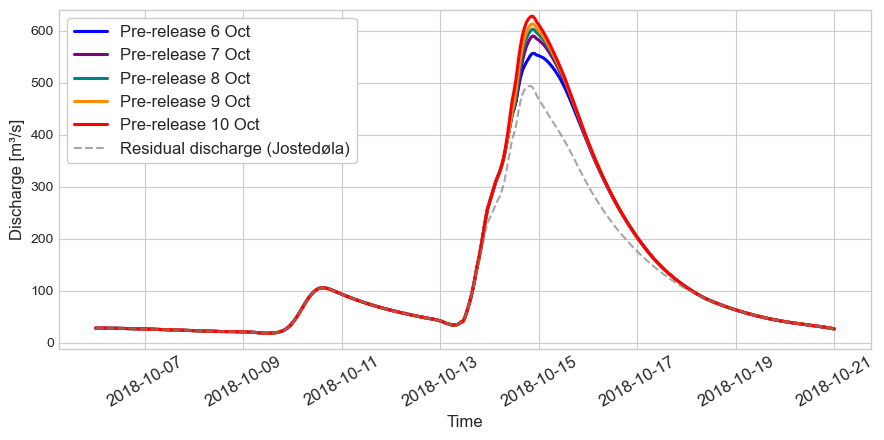

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_feather("Jost_Gaupne/results_20_6th/flow.arrow")
df2 = pd.read_feather("Jost_Gaupne/results_20_7th/flow.arrow")
df3 = pd.read_feather("Jost_Gaupne/results_20_8th/flow.arrow")
df4 = pd.read_feather("Jost_Gaupne/results_20_9th/flow.arrow")
df5 = pd.read_feather("Jost_Gaupne/results_20_10th/flow.arrow")

dfs = [df1, df2, df3, df4, df5]

for df in dfs:
    df["time"] = pd.to_datetime(df["time"])

def extract(df, link_id):
    return df[df["link_id"] == link_id]

gauges = [extract(df, 20) for df in dfs]


gau_unreg = extract(df1, 19)


start = "2018-10-06"
end   = "2018-10-21"

def clip(df):
    return df[(df["time"] >= start) & (df["time"] <= end)]

gauges = [clip(g) for g in gauges]
gau_unreg = clip(gau_unreg)

def get_peak(df):
    idx = df["flow_rate"].idxmax()
    return df.loc[idx, "flow_rate"], df.loc[idx, "time"]

peaks = [get_peak(g) for g in gauges]

# Printing summary of peaks: 
labels = ["6 Oct", "7 Oct", "8 Oct", "9 Oct", "10 Oct"]
for lab, (p, t) in zip(labels, peaks):
    print(f"{lab}: {p:.1f} m³/s at {t}")

peak_res, time_res = get_peak(gau_unreg)
print(f"Residual peak: {peak_res:.1f} m³/s at {time_res}")

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 4.5))

colors = ["blue", "purple", "teal", "darkorange", "red"]


for g, lab, col in zip(gauges, labels, colors):
    ax.plot(
        g["time"], g["flow_rate"],
        linewidth=2.2,
        color=col,
        label=f"Pre-release {lab}"
    )

ax.plot(
    gau_unreg["time"], gau_unreg["flow_rate"],
    color="gray", linestyle="--", linewidth=1.5,
    alpha=0.7,
    label="Residual discharge (Jostedøla)"
)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Discharge [m³/s]", fontsize=12)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="0.8",
    fontsize=12
)

plt.ylim(top=640)
# plt.ylim(bottom=300)
plt.xticks(rotation=30, fontsize=12)

plt.tight_layout()
plt.show()

### Spill plots: 

Pre-release from 9 Oct: 49.26 m³/s at 2018-10-15 16:00:00
Pre-release from 8 Oct: 45.01 m³/s at 2018-10-15 18:00:00
Pre-release from 7 Oct: 39.66 m³/s at 2018-10-15 20:00:00
Pre-release from 6 Oct: 26.18 m³/s at 2018-10-16 04:00:00


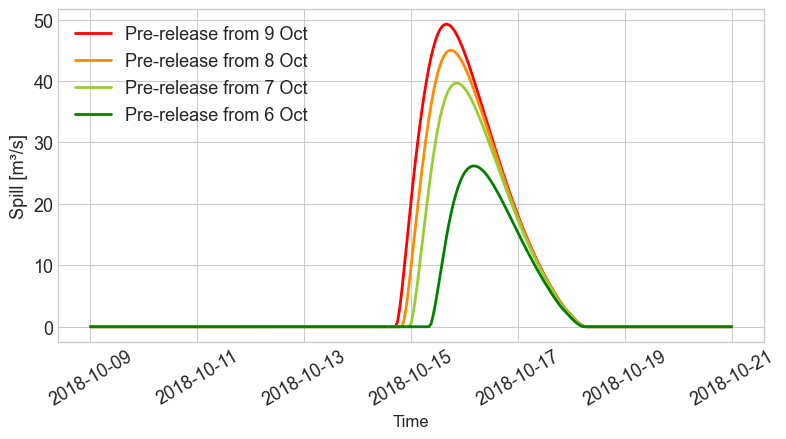

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 20% increased precipitation scenarios: 
# scenarios = {
#     "Pre-release from 9 Oct": "results_20_9th",
#     "Pre-release from 8 Oct": "results_20_8th",
#     "Pre-release from 7 Oct": "results_20_7th",
#     "Pre-release from 6 Oct": "results_20_6th",
# }

# Observed precipitation scenarios: 
scenarios = {
    "Pre-release from 9 Oct": "results_ex3_9th",
    "Pre-release from 8 Oct": "results_ex3_8th",
    "Pre-release from 7 Oct": "results_ex3_7th",
    "Pre-release from 6 Oct": "results_ex1",
}

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(8, 4.5))

colors = ["red", "darkorange", "yellowgreen", "green", "blue"]

for i, (label, result_file) in enumerate(scenarios.items()):

    df_flow = pd.read_feather(f"Jost_Gaupne/{result_file}/flow.arrow")

    df_flow["time"] = pd.to_datetime(df_flow["time"])
    df_sel = df_flow[df_flow["link_id"].isin(range(1, 21))]
    df_3 = df_sel[df_sel["link_id"] == 3]

    mask = (
        (df_3["time"] >= "2018-10-09") &
        (df_3["time"] <= "2018-10-21")
    )
    df_3 = df_3.loc[mask]

    peak_idx = df_3["flow_rate"].idxmax()

    peak_value = df_3.loc[peak_idx, "flow_rate"]
    peak_time = df_3.loc[peak_idx, "time"]

    print(f"{label}: {peak_value:.2f} m³/s at {peak_time}")

    plt.plot(
        df_3["time"],
        df_3["flow_rate"],
        # linestyle="--",
        linewidth=2,
        label=label,
        color=colors[i]
    )

plt.xlabel("Time", fontsize=12)
plt.ylabel("Spill [m³/s]", fontsize=13)

plt.xticks(rotation=30, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(loc="upper left", fontsize=13)

plt.tight_layout()

plt.show()

##### Printing and plotting spill peaks

a) Observed precipitation | Pre-release from 9 Oct
Peak spill: 49.26 m³/s at 2018-10-15 16:00:00

a) Observed precipitation | Pre-release from 8 Oct
Peak spill: 45.01 m³/s at 2018-10-15 18:00:00

a) Observed precipitation | Pre-release from 7 Oct
Peak spill: 39.66 m³/s at 2018-10-15 20:00:00

a) Observed precipitation | Pre-release from 6 Oct
Peak spill: 26.18 m³/s at 2018-10-16 04:00:00

b) +20% precipitation | Pre-release from 9 Oct
Peak spill: 83.93 m³/s at 2018-10-15 05:00:00

b) +20% precipitation | Pre-release from 8 Oct
Peak spill: 79.55 m³/s at 2018-10-15 07:00:00

b) +20% precipitation | Pre-release from 7 Oct
Peak spill: 74.70 m³/s at 2018-10-15 09:00:00

b) +20% precipitation | Pre-release from 6 Oct
Peak spill: 63.44 m³/s at 2018-10-15 14:00:00



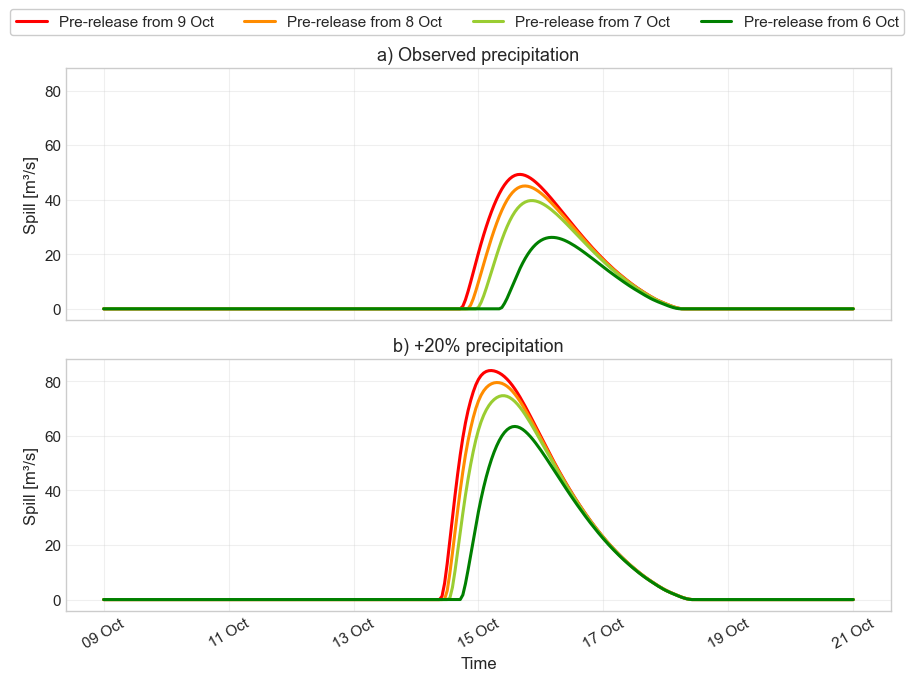

In [ ]:

scenarios_obs = {
    "Pre-release from 9 Oct": "results_ex3_9th",
    "Pre-release from 8 Oct": "results_ex3_8th",
    "Pre-release from 7 Oct": "results_ex3_7th",
    "Pre-release from 6 Oct": "results_ex1",
}

scenarios_20 = {
    "Pre-release from 9 Oct": "results_20_9th",
    "Pre-release from 8 Oct": "results_20_8th",
    "Pre-release from 7 Oct": "results_20_7th",
    "Pre-release from 6 Oct": "results_20_6th",
}

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

colors = {
    "Pre-release from 6 Oct": "green",
    "Pre-release from 7 Oct": "yellowgreen",
    "Pre-release from 8 Oct": "darkorange",
    "Pre-release from 9 Oct": "red",
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True,
    sharey=True
)

def plot_spill(ax, scenarios, panel_title):

    for label, result_file in scenarios.items():

        df_flow = pd.read_feather(
            f"Jost_Gaupne/{result_file}/flow.arrow"
        )

        df_flow["time"] = pd.to_datetime(df_flow["time"])

        df_3 = df_flow[df_flow["link_id"] == 3]

        mask = (
            (df_3["time"] >= "2018-10-09") &
            (df_3["time"] <= "2018-10-21")
        )

        df_3 = df_3.loc[mask]

        peak_idx = df_3["flow_rate"].idxmax()

        peak_value = df_3.loc[peak_idx, "flow_rate"]
        peak_time = df_3.loc[peak_idx, "time"]

        print(f"{panel_title} | {label}")
        print(f"Peak spill: {peak_value:.2f} m³/s at {peak_time}\n")

        ax.plot(
            df_3["time"],
            df_3["flow_rate"],
            linewidth=2.2,
            label=label,
            color=colors[label]
        )

        forecast_day = label.split()[2]

        forecast_time = pd.Timestamp(
            f"2018-10-{int(forecast_day):02d}"
        )

    ax.set_title(panel_title, fontsize=13)

    ax.set_ylabel("Spill [m³/s]")

    ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%d %b")
    )

plot_spill(
    axes[0],
    scenarios_obs,
    "a) Observed precipitation"
)

plot_spill(
    axes[1],
    scenarios_20,
    "b) +20% precipitation"
)

axes[1].set_xlabel("Time")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=True,
    facecolor="white",
    framealpha=1,
    bbox_to_anchor=(0.5, 0.98)
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()

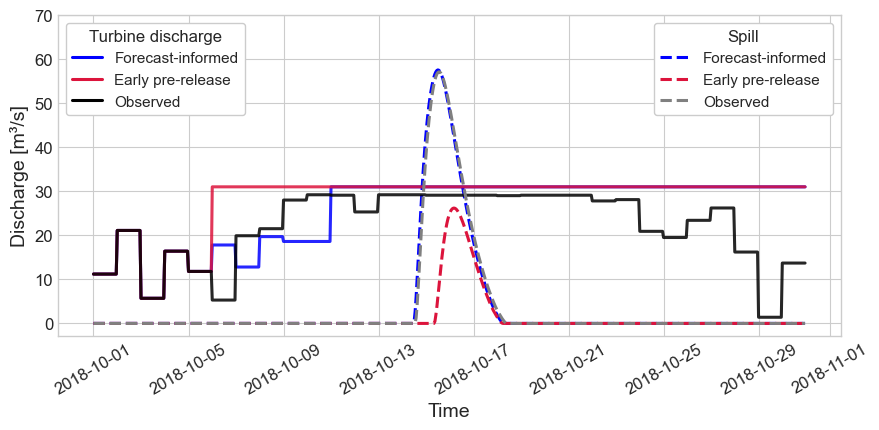

Forecast-based: 57.53 m³/s at 2018-10-15 12:00:00
Observed: 57.10 m³/s at 2018-10-15 13:00:00
Early pre-release: 26.18 m³/s at 2018-10-16 04:00:00


In [ ]:

df_flow  = pd.read_feather("Jost_Gaupne/results_ex2/flow.arrow")
df_flow2 = pd.read_feather("Jost_Gaupne/results_ex0/flow.arrow")
df_flow3 = pd.read_feather("Jost_Gaupne/results_ex1/flow.arrow")

for df in [df_flow, df_flow2, df_flow3]:
    df["time"] = pd.to_datetime(df["time"])

def extract_spill(df):
    df_sel = df[df["link_id"].isin(range(1, 21))]
    return df_sel[df_sel["link_id"] == 3]

df_3          = extract_spill(df_flow)
df_realspill  = extract_spill(df_flow2)
df_leastspill = extract_spill(df_flow3)

df_turbine  = df_flow[df_flow["link_id"] == 5]
df_turbine2 = df_flow2[df_flow2["link_id"] == 5]
df_turbine3 = df_flow3[df_flow3["link_id"] == 5]

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    df_turbine["time"], df_turbine["flow_rate"],
    linewidth=2.2,
    color="blue",
    alpha=0.85,
    label="Turbine: forecast-based"
)
ax.plot(
    df_3["time"], df_3["flow_rate"],
    linestyle="--", linewidth=2.2,
    color="blue",
    label="Spill: forecast-based"
)


ax.plot(
    df_turbine3["time"], df_turbine3["flow_rate"],
    linewidth=2.2,
    color="crimson",
    alpha=0.85,
    label="Turbine: early pre-release"
)
ax.plot(
    df_leastspill["time"], df_leastspill["flow_rate"],
    linestyle="--", linewidth=2.2,
    color="crimson",
    label="Spill: early pre-release"
)

ax.plot(
    df_turbine2["time"], df_turbine2["flow_rate"],
    linewidth=2.2,
    color="black",
    alpha=0.85,
    label="Turbine: observed operation"
)
ax.plot(
    df_realspill["time"], df_realspill["flow_rate"],
    linestyle="--", linewidth=2.2,
    color="gray",
    label="Spill: observed operation"
)

ax.set_xlabel("Time")
ax.set_ylabel("Discharge [m³/s]")

turbine_handles = [
    Line2D([0], [0], color="blue", lw=2.2),
    Line2D([0], [0], color="crimson", lw=2.2),
    Line2D([0], [0], color="black", lw=2.2),
]

turbine_labels = [
    "Forecast-informed",
    "Early pre-release",
    "Observed",
]

legend1 = ax.legend(
    turbine_handles,
    turbine_labels,
    title="Turbine discharge",
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="0.8",
    fontsize=11,
    title_fontsize=12,
)

ax.add_artist(legend1)

spill_handles = [
    Line2D([0], [0], color="blue", lw=2.2, linestyle="--"),
    Line2D([0], [0], color="crimson", lw=2.2, linestyle="--"),
    Line2D([0], [0], color="gray", lw=2.2, linestyle="--"),
]

spill_labels = [
    "Forecast-informed",
    "Early pre-release",
    "Observed",
]

legend2 = ax.legend(
    spill_handles,
    spill_labels,
    title="Spill",
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=1,
    edgecolor="0.8",
    fontsize=11,
    title_fontsize=12,
)

plt.xticks(rotation=30)

ax.set_ylim(top=70)

plt.tight_layout()

plt.show()

def print_peak(df, label):
    idx = df["flow_rate"].idxmax()
    peak = df.loc[idx, "flow_rate"]
    time = df.loc[idx, "time"]
    print(f"{label}: {peak:.2f} m³/s at {time}")

print_peak(df_3, "Forecast-based")
print_peak(df_realspill, "Observed")
print_peak(df_leastspill, "Early pre-release")

##### Volume calculations:

In [ ]:
def calculate_volume(df, label, end_date="2018-10-14"):
    
    df_sel = df[df["time"] <= pd.Timestamp(end_date)].copy()

    df_sel = df_sel.sort_values("time")
    dt = df_sel["time"].diff().dt.total_seconds()
    dt.iloc[0] = dt.iloc[1]
    volume_m3 = (df_sel["flow_rate"] * dt).sum()
    volume_mcm = volume_m3 / 1e6

    print(f"{label}:")
    print(f"  Total discharged volume = {volume_m3:,.0f} m³")
    print(f"  = {volume_mcm:.3f} million m³\n")

# Turbine discharge volumes
calculate_volume(df_turbine,  "Forecast-based turbine")
calculate_volume(df_turbine2, "Observed turbine")
calculate_volume(df_turbine3, "Early pre-release turbine")

Forecast-based turbine:
  Total discharged volume = 21,426,481 m³
  = 21.426 million m³

Observed turbine:
  Total discharged volume = 22,024,798 m³
  = 22.025 million m³

Early pre-release turbine:
  Total discharged volume = 27,258,477 m³
  = 27.258 million m³



C:\Users\Eline Karijord\AppData\Local\Temp\ipykernel_15464\1122460686.py:16: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt.iloc[0] = dt.iloc[1]


#### Tubrine discharge and spill plot

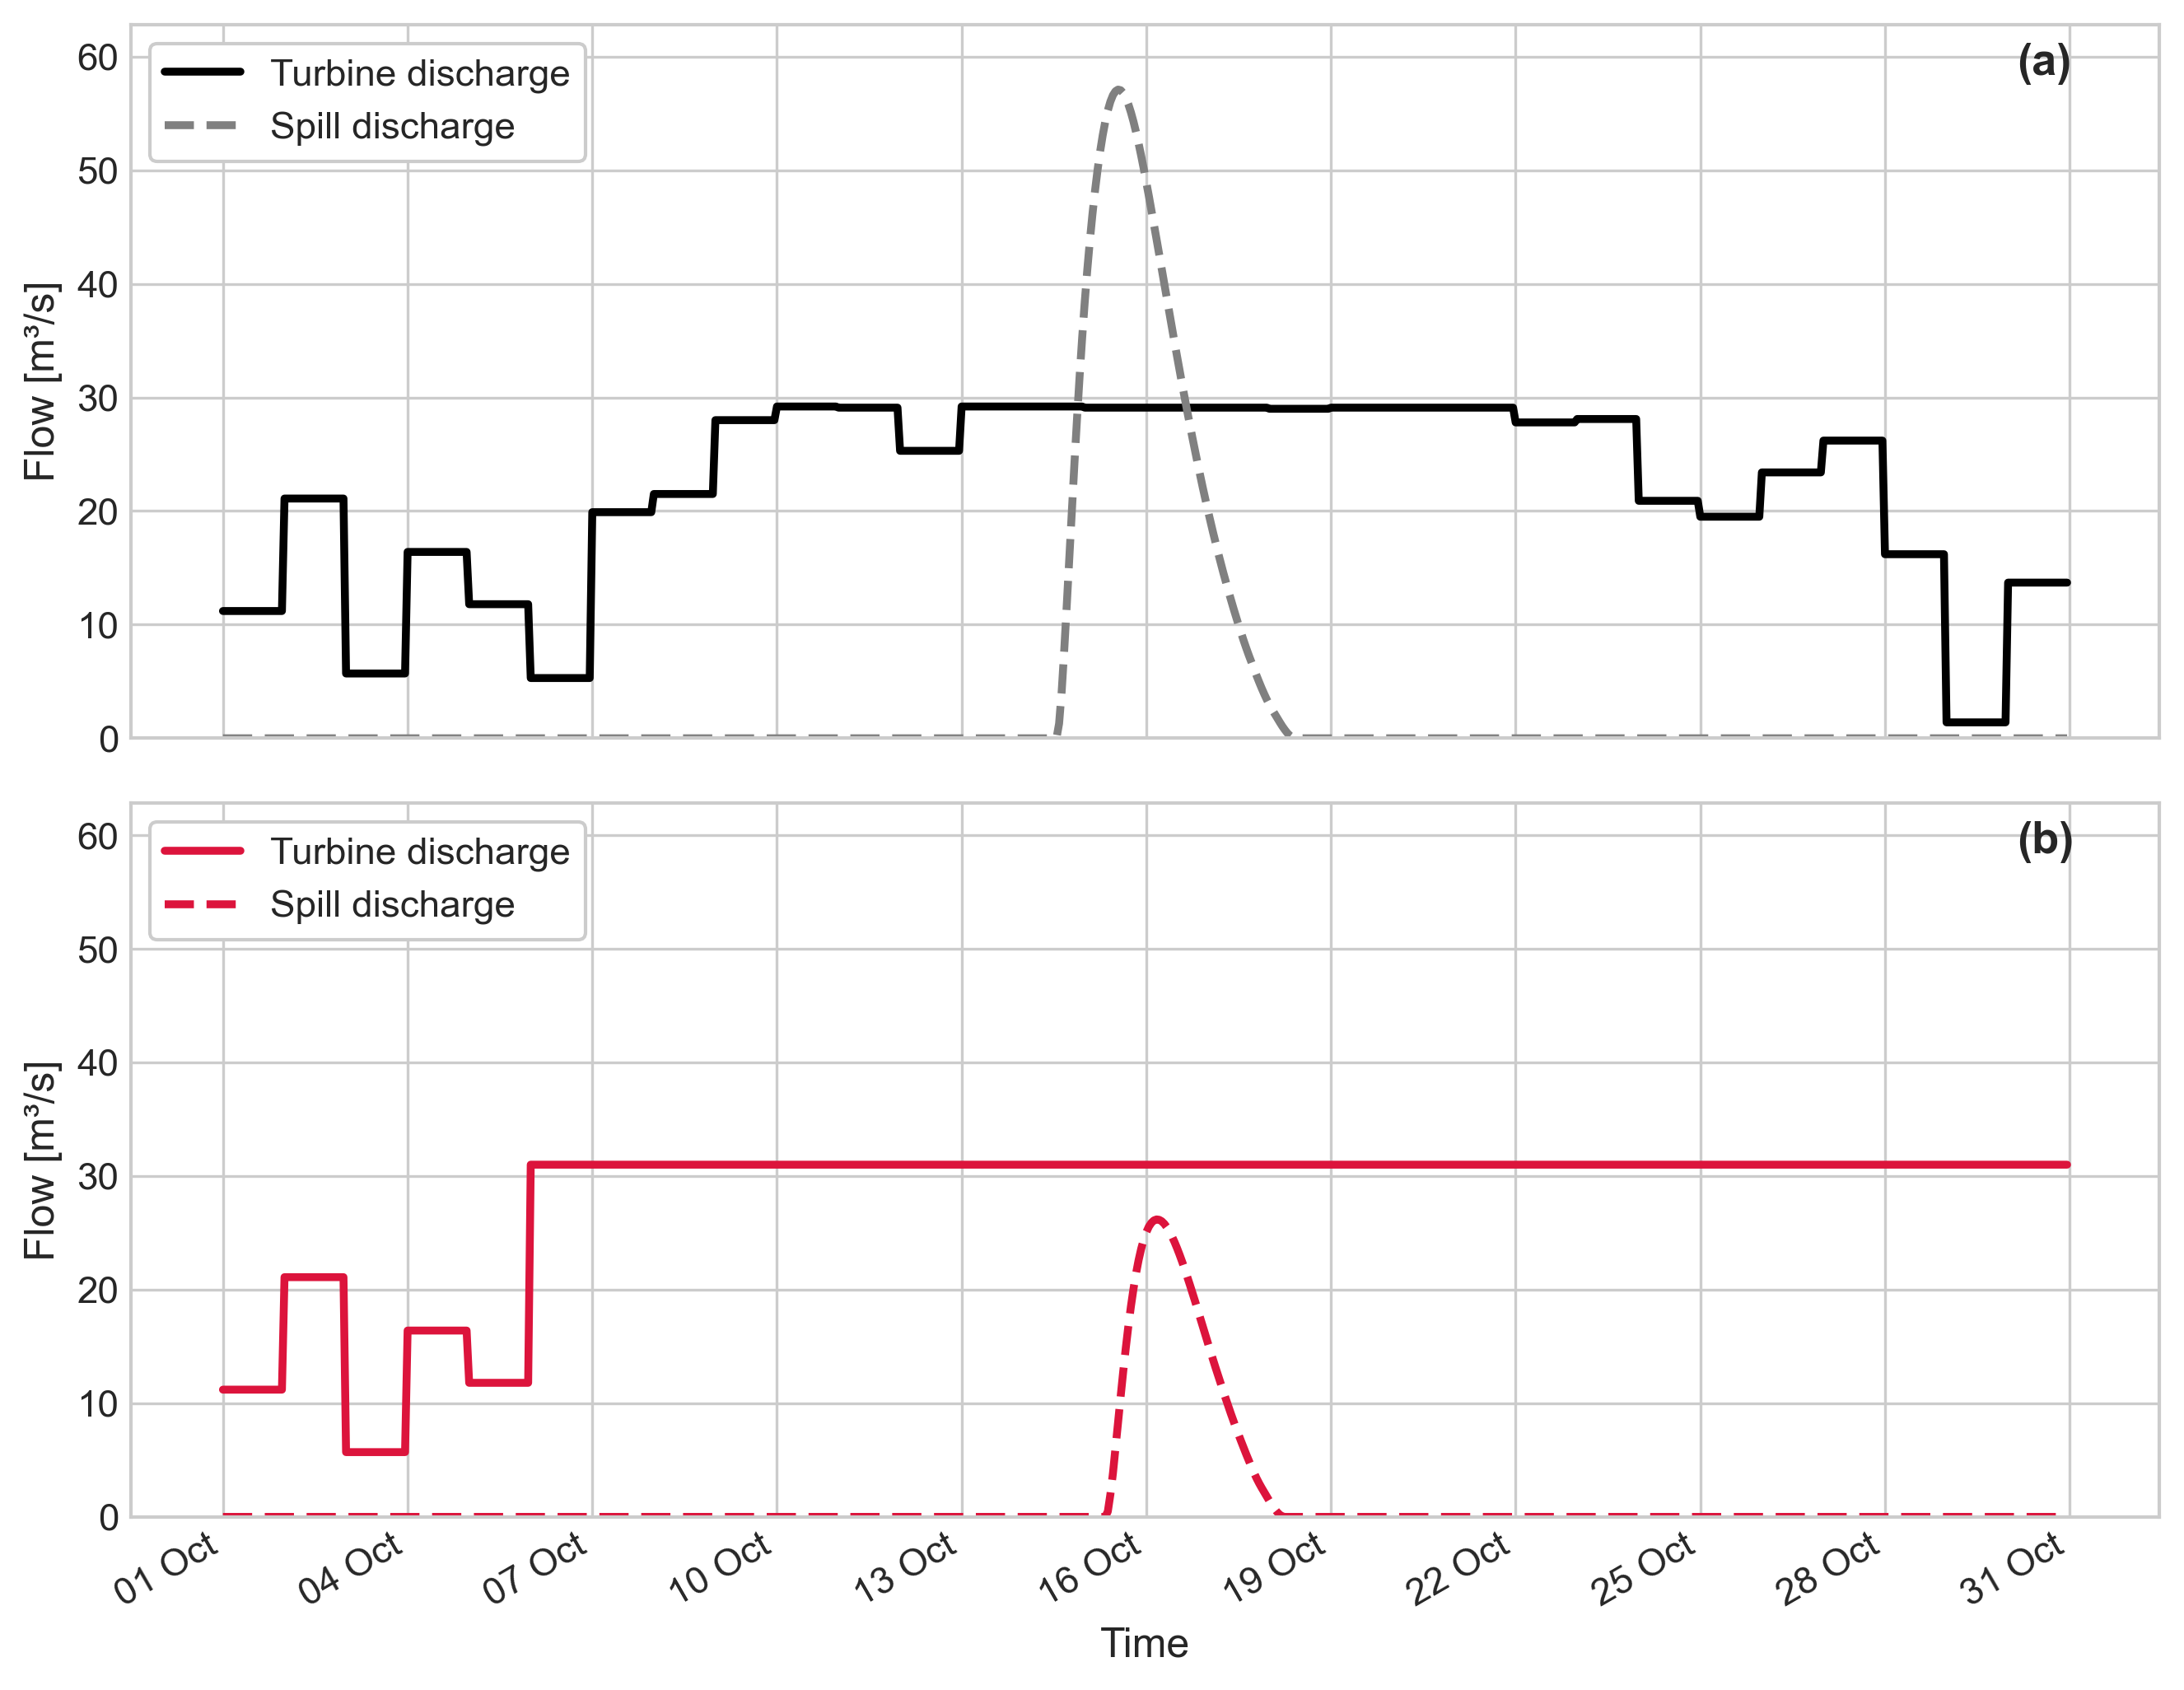

Baseline scenario: 57.10 m³/s at 2018-10-15 13:00:00
Maximum turbine discharge from 6 October: 26.18 m³/s at 2018-10-16 04:00:00


In [ ]:

df_flow_baseline = pd.read_feather(
    "Jost_Gaupne/results_ex0/flow.arrow"
)

df_flow_maxprod = pd.read_feather(
    "Jost_Gaupne/results_ex1/flow.arrow"
)
for df in [df_flow_baseline, df_flow_maxprod]:
    df["time"] = pd.to_datetime(df["time"])


def extract_spill(df):

    df_sel = df[df["link_id"].isin(range(1, 21))]
    return df_sel[df_sel["link_id"] == 3]

df_spill_baseline = extract_spill(df_flow_baseline)
df_spill_maxprod = extract_spill(df_flow_maxprod)


df_turbine_baseline = df_flow_baseline[
    df_flow_baseline["link_id"] == 5
]

df_turbine_maxprod = df_flow_maxprod[
    df_flow_maxprod["link_id"] == 5
]


plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 7),
    sharex=True
)

ax1.plot(
    df_turbine_baseline["time"],
    df_turbine_baseline["flow_rate"],
    color="black",
    linewidth=2.3,
    label="Turbine discharge"
)

ax1.plot(
    df_spill_baseline["time"],
    df_spill_baseline["flow_rate"],
    linestyle="--",
    color="gray",
    linewidth=2.3,
    label="Spill discharge"
)

ax1.set_ylabel("Flow [m³/s]")

leg1 = ax1.legend(
    loc="upper left",
    frameon=True
)

leg1.get_frame().set_facecolor("white")
leg1.get_frame().set_edgecolor("0.8")
leg1.get_frame().set_alpha(1)

ax2.plot(
    df_turbine_maxprod["time"],
    df_turbine_maxprod["flow_rate"],
    color="crimson",
    linewidth=2.3,
    label="Turbine discharge"
)

ax2.plot(
    df_spill_maxprod["time"],
    df_spill_maxprod["flow_rate"],
    linestyle="--",
    color="crimson",
    linewidth=2.3,
    label="Spill discharge"
)

ax2.set_ylabel("Flow [m³/s]")
ax2.set_xlabel("Time")

leg2 = ax2.legend(
    loc="upper left",
    frameon=True
)

leg2.get_frame().set_facecolor("white")
leg2.get_frame().set_edgecolor("0.8")
leg2.get_frame().set_alpha(1)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b')
)

ax2.xaxis.set_major_locator(
    mdates.DayLocator(interval=3)
)

plt.xticks(rotation=30, ha="right")

ymax = max(
    df_turbine_baseline["flow_rate"].max(),
    df_spill_baseline["flow_rate"].max(),
    df_turbine_maxprod["flow_rate"].max(),
    df_spill_maxprod["flow_rate"].max()
)

ax1.set_ylim(0, ymax * 1.1)
ax2.set_ylim(0, ymax * 1.1)
ax1.text(
    0.93, 0.93,
    "(a)",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold"
)

ax2.text(
    0.93, 0.93,
    "(b)",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Printing peak spill values
def print_peak(df, label):

    idx = df["flow_rate"].idxmax()

    peak = df.loc[idx, "flow_rate"]
    time = df.loc[idx, "time"]

    print(
        f"{label}: {peak:.2f} m³/s at {time}"
    )

print_peak(
    df_spill_baseline,
    "Baseline scenario"
)

print_peak(
    df_spill_maxprod,
    "Maximum turbine discharge from 6 October"
)